# 人工智能相关招聘岗位需求、薪资与技能关键词可视化分析
按“**数据概览 → 城市需求 → 薪资水平 → 学历/公司/行业 → 岗位类型 → 技能关键词 → 交叉关系与综合分析**”的逻辑逐层展开

In [3]:


from pathlib import Path
from itertools import combinations
import os
import re
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle
from IPython.display import display

warnings.filterwarnings("ignore")

# 数据路径：推荐保持相对路径。你的数据文件夹和 notebook 在同一目录下时，不需要写完整 C 盘路径。
DATA_PATH = Path("data_clean")

# 如果上面的 data_clean 文件夹不存在，会自动尝试寻找 data_clean(1).zip、data_clean.zip 或当前目录下的 csv 文件
OUTPUT_DIR = Path("结果可视化")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 为避免重复运行时保留旧图片，先清空输出目录中已有的 png 文件
for _old_png in OUTPUT_DIR.glob("*.png"):
    try:
        _old_png.unlink()
    except Exception:
        pass

# 常用展示参数
TOP_N_CITY = 15
TOP_N_JOB = 15
TOP_N_SKILL = 25
TOP_N_INDUSTRY = 15
TOP_N_HEATMAP_CITY = 12
TOP_N_HEATMAP_JOB = 12
COLORS = {
    "indigo": "#4F46E5",
    "blue": "#2563EB",
    "sky": "#0EA5E9",
    "cyan": "#06B6D4",
    "teal": "#14B8A6",
    "green": "#10B981",
    "lime": "#84CC16",
    "yellow": "#FACC15",
    "amber": "#F59E0B",
    "orange": "#F97316",
    "red": "#EF4444",
    "rose": "#F43F5E",
    "pink": "#EC4899",
    "purple": "#8B5CF6",
    "violet": "#7C3AED",
    "brown": "#A16207",
    "gray": "#64748B",
    "light_gray": "#CBD5E1",
    "dark": "#1F2937",
    "grid": "#E2E8F0",
    "light_bg": "#F8FAFC",
}
PALETTE = [
    COLORS["blue"], COLORS["cyan"], COLORS["green"], COLORS["amber"], COLORS["rose"],
    COLORS["purple"], COLORS["teal"], COLORS["orange"], COLORS["indigo"], COLORS["pink"]
]

EDU_ORDER = ["不限", "大专", "本科", "硕士", "博士"]
SALARY_TIER_ORDER = ["3k以下", "3-6k", "6-10k", "10-15k", "15-20k", "20k以上"]
CITY_COORDS = {
    "北京": (116.4074, 39.9042), "上海": (121.4737, 31.2304), "广州": (113.2644, 23.1291),
    "深圳": (114.0579, 22.5431), "杭州": (120.1551, 30.2741), "成都": (104.0665, 30.5728),
    "南京": (118.7969, 32.0603), "武汉": (114.3054, 30.5928), "长沙": (112.9388, 28.2282),
    "重庆": (106.5516, 29.5630), "西安": (108.9398, 34.3416), "苏州": (120.5853, 31.2989),
    "无锡": (120.3119, 31.4912), "合肥": (117.2272, 31.8206), "厦门": (118.0894, 24.4798),
    "天津": (117.2000, 39.1333), "郑州": (113.6254, 34.7466), "佛山": (113.1214, 23.0215),
    "青岛": (120.3826, 36.0671), "宁波": (121.5503, 29.8746),
}
SKILL_KEYWORDS = [
    "人工智能", "机器学习", "深度学习", "大模型", "AIGC", "NLP", "自然语言处理", "计算机视觉", "CV",
    "推荐算法", "算法", "数据分析", "数据挖掘", "数据仓库", "数据工程", "Python", "Java", "C++", "C#",
    "Go", "SQL", "MySQL", "Redis", "Linux", "Git", "Docker", "Kubernetes", "Spark", "Hadoop", "Hive", "Flink",
    "TensorFlow", "PyTorch", "PaddlePaddle", "前端", "后端", "客户端", "测试", "运维", "产品", "运营", "UI", "交互", "游戏开发", "嵌入式"
]


In [4]:

def setup_chinese_font():
    """设置中文字体，避免中文标题、坐标轴乱码。"""
    candidate_paths = [
        "C:/Windows/Fonts/msyh.ttc",
        "C:/Windows/Fonts/simhei.ttf",
        "C:/Windows/Fonts/simsun.ttc",
        "/System/Library/Fonts/PingFang.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
    ]
    font_name = None
    for fp in candidate_paths:
        if os.path.exists(fp):
            try:
                font_manager.fontManager.addfont(fp)
                font_name = font_manager.FontProperties(fname=fp).get_name()
                break
            except Exception:
                pass
    if font_name:
        plt.rcParams["font.sans-serif"] = [font_name, "Microsoft YaHei", "SimHei", "Arial Unicode MS"]
    else:
        plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.dpi"] = 130
    plt.rcParams["savefig.dpi"] = 240
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"
    plt.rcParams["axes.titleweight"] = "bold"
    plt.rcParams["axes.edgecolor"] = COLORS["light_gray"]
    plt.rcParams["xtick.color"] = COLORS["dark"]
    plt.rcParams["ytick.color"] = COLORS["dark"]


def find_chinese_font_path():
    """词云等需要字体文件路径时使用。"""
    candidates = [
        "C:/Windows/Fonts/msyh.ttc",
        "C:/Windows/Fonts/simhei.ttf",
        "C:/Windows/Fonts/simsun.ttc",
        "/System/Library/Fonts/PingFang.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
    ]
    for fp in candidates:
        if os.path.exists(fp):
            return fp
    return None


def smart_read_csv(path):
    """兼容常见中文编码。"""
    for enc in ["utf-8-sig", "utf-8", "gbk", "gb18030"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    return pd.read_csv(path)


def resolve_data_file(data_path=DATA_PATH):
    """自动识别 data_clean 文件夹、zip 压缩包或 csv 文件。"""
    data_path = Path(data_path)

    if data_path.is_dir():
        csv_files = sorted(data_path.glob("*.csv"))
        if not csv_files:
            raise FileNotFoundError(f"{data_path} 文件夹下没有找到 csv 文件。")
        for f in csv_files:
            if "jobs" in f.name or "cleaned" in f.name:
                return f
        return csv_files[0]

    if data_path.is_file() and data_path.suffix.lower() == ".csv":
        return data_path

    if data_path.is_file() and data_path.suffix.lower() == ".zip":
        extract_dir = Path("_data_clean_extract")
        extract_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(data_path, "r") as zf:
            zf.extractall(extract_dir)
        csv_files = sorted(extract_dir.rglob("*.csv"))
        for f in csv_files:
            if "jobs" in f.name or "cleaned" in f.name:
                return f
        if csv_files:
            return csv_files[0]

    for candidate in [Path("data_clean"), Path("data_clean(1).zip"), Path("data_clean.zip")]:
        if candidate.exists():
            return resolve_data_file(candidate)
    csv_files = sorted(Path.cwd().glob("*.csv"))
    if csv_files:
        return csv_files[0]

    raise FileNotFoundError("没有找到数据文件。请确认 data_clean 文件夹或 data_clean(1).zip 与 Notebook 在同一目录下。")


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    """统一图表风格：更清爽、更亮、更适合展示。"""
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(COLORS["light_gray"])
    ax.spines["bottom"].set_color(COLORS["light_gray"])
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(colors=COLORS["dark"], labelsize=10)
    if grid_axis:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.8, alpha=0.9, color=COLORS["grid"])
        ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=16, fontweight="bold", color=COLORS["dark"], pad=16)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=COLORS["dark"], labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=COLORS["dark"], labelpad=8)


def save_and_show(fig, filename):
    """每张图先保存，再在 Notebook 中直接显示。"""
    file_path = OUTPUT_DIR / filename
    fig.savefig(file_path, bbox_inches="tight", facecolor="white")
    print(f"已保存：{file_path}")
    plt.show()
    plt.close(fig)


def add_bar_labels(ax, bars, fmt="{:.0f}", horizontal=False, fontsize=9):
    """给柱状图添加数值标签。"""
    if horizontal:
        xmax = ax.get_xlim()[1]
        for bar in bars:
            value = bar.get_width()
            ax.text(value + xmax * 0.012, bar.get_y() + bar.get_height()/2,
                    fmt.format(value), ha="left", va="center", fontsize=fontsize, color=COLORS["dark"])
    else:
        ymax = ax.get_ylim()[1]
        for bar in bars:
            value = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, value + ymax * 0.012,
                    fmt.format(value), ha="center", va="bottom", fontsize=fontsize, color=COLORS["dark"])


def shorten_label(x, max_len=12):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len] + "…"


def normalize_series(s):
    """用于雷达图等场景，把指标归一化到 0-1。"""
    s = pd.Series(s).astype(float)
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())


def get_discrete_colors(n):
    return [PALETTE[i % len(PALETTE)] for i in range(n)]


def is_meaningful_category(series, min_unique=2, max_top_ratio=0.97):
    """判断分类图是否有分析意义：至少 2 类，且不能几乎被单一类别垄断。"""
    s = pd.Series(series).dropna().astype(str)
    if len(s) == 0 or s.nunique() < min_unique:
        return False
    top_ratio = s.value_counts(normalize=True).iloc[0]
    return top_ratio < max_top_ratio


def is_meaningful_numeric(series, min_non_na=10):
    s = pd.to_numeric(pd.Series(series), errors="coerce").dropna()
    return len(s) >= min_non_na and s.nunique() > 1


def skip_plot(reason):
    print(f"跳过该图：{reason}")

setup_chinese_font()
print(f"输出文件夹：{OUTPUT_DIR.resolve()}")


输出文件夹：C:\Users\liangxixi\Desktop\大三下\数据可视化\期末\结果可视化


## 一、读取数据与基础检查

In [5]:


data_file = resolve_data_file(DATA_PATH)
print(f"当前读取的数据文件：{data_file}")

raw_df = smart_read_csv(data_file)
df = raw_df.copy()

if "city_clean" in df.columns:
    df["city_use"] = df["city_clean"]
elif "city" in df.columns:
    df["city_use"] = df["city"]
else:
    df["city_use"] = "未知"

if "company_size_clean" in df.columns:
    df["company_size_use"] = df["company_size_clean"]
elif "company_size" in df.columns:
    df["company_size_use"] = df["company_size"]
else:
    df["company_size_use"] = "未知"

if "search_keyword" not in df.columns:
    df["search_keyword"] = "未知岗位"

if "education" not in df.columns:
    df["education"] = "未知"

if "experience" not in df.columns:
    df["experience"] = "未知"

if "industry" not in df.columns:
    df["industry"] = "未知"

# 薪资中位字段，优先使用已清洗好的 salary_mid
if "salary_mid" in df.columns:
    df["salary_mid"] = pd.to_numeric(df["salary_mid"], errors="coerce")
elif {"salary_min", "salary_max"}.issubset(df.columns):
    df["salary_mid"] = (pd.to_numeric(df["salary_min"], errors="coerce") + pd.to_numeric(df["salary_max"], errors="coerce")) / 2
else:
    df["salary_mid"] = np.nan

if "salary_min" in df.columns:
    df["salary_min"] = pd.to_numeric(df["salary_min"], errors="coerce")
else:
    df["salary_min"] = df["salary_mid"]

if "salary_max" in df.columns:
    df["salary_max"] = pd.to_numeric(df["salary_max"], errors="coerce")
else:
    df["salary_max"] = df["salary_mid"]

# 薪资档位，如果原数据已有则沿用，否则自动生成
if "salary_tier" not in df.columns:
    bins = [-np.inf, 3, 6, 10, 15, 20, np.inf]
    labels = ["3k以下", "3-6k", "6-10k", "10-15k", "15-20k", "20k以上"]
    df["salary_tier"] = pd.cut(df["salary_mid"], bins=bins, labels=labels).astype(str)

# 学历分数，如果原数据没有则自动映射
edu_score_map = {"不限": 0, "大专": 1, "本科": 2, "硕士": 3, "博士": 4}
if "edu_score" not in df.columns:
    df["edu_score"] = df["education"].map(edu_score_map).fillna(0)

# 竞争力分数，如果原数据没有则用薪资和学历做一个简单代理指标
if "competitiveness_score" not in df.columns:
    df["competitiveness_score"] = normalize_series(df["salary_mid"].fillna(df["salary_mid"].median())) * 0.7 + normalize_series(df["edu_score"].fillna(0)) * 0.3

# 技能关键词匹配：从 job_title、search_keyword、industry 三个字段中提取
text_cols = [c for c in ["job_title", "search_keyword", "industry"] if c in df.columns]
df["skill_text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

def extract_skills(text):
    text = str(text)
    found = []
    for kw in SKILL_KEYWORDS:
        if kw.lower() in text.lower():
            found.append(kw)
    return found

df["skills"] = df["skill_text"].apply(extract_skills)
df["skill_count"] = df["skills"].apply(len)

print(f"数据规模：{df.shape[0]} 行，{df.shape[1]} 列")
display(df.head())

当前读取的数据文件：data_clean\shixiseng_jobs_cleaned.csv
数据规模：8149 行，25 列


,job_title,company_name,city,search_keyword,salary_raw,salary_min,salary_max,education,experience,duration,...,salary_valid,salary_mid,salary_tier,edu_score,competitiveness_score,city_use,company_size_use,skill_text,skills,skill_count
0,后端开发实习生-音乐,NaN,北京,Java开发,500-500,11.0,11.0,本科,不限,不限,...,True,11.0,10-15k,2,0.8,北京,50人以下,后端开发实习生-音乐 Java开发 互联网/游戏/软件,"[Java, 后端]",2
1,AI开发实习生-抖音研发,NaN,北京,Java开发,500-500,11.0,11.0,本科,不限,不限,...,True,11.0,10-15k,2,0.8,北京,50人以下,AI开发实习生-抖音研发 Java开发 互联网/游戏/软件,[Java],1
2,后端开发实习生-剪映0ap001,NaN,北京,Java开发,500-500,11.0,11.0,本科,不限,不限,...,True,11.0,10-15k,2,0.8,北京,50人以下,后端开发实习生-剪映0ap001 Java开发 互联网/游戏/软件,"[Java, 后端]",2
3,后端开发实习生-抖音服务架构,NaN,北京,Java开发,500-500,11.0,11.0,本科,不限,不限,...,True,11.0,10-15k,2,0.8,北京,50人以下,后端开发实习生-抖音服务架构 Java开发 互联网/游戏/软件,"[Java, 后端]",2
4,后端开发实习生-抖音研发（北京/上海/深圳）,NaN,北京,Java开发,500-500,11.0,11.0,本科,不限,不限,...,True,11.0,10-15k,2,0.8,北京,50人以下,后端开发实习生-抖音研发（北京/上海/深圳） Java开发 互联网/游戏/软件,"[Java, 后端]",2


In [6]:
# 字段类型、缺失率和核心字段唯一值情况
# 注意：skills 字段是列表类型，直接 nunique 会报 unhashable type: list，因此这里做了安全处理。
def safe_nunique(series):
    try:
        return series.nunique(dropna=True)
    except TypeError:
        return series.astype(str).nunique(dropna=True)

info_table = pd.DataFrame({
    "字段": df.columns,
    "数据类型": [str(df[c].dtype) for c in df.columns],
    "缺失数量": [df[c].isna().sum() for c in df.columns],
    "缺失率": [f"{df[c].isna().mean()*100:.2f}%" for c in df.columns],
    "唯一值数量": [safe_nunique(df[c]) for c in df.columns],
})

display(info_table)

core_summary = pd.DataFrame({
    "指标": ["岗位记录数", "城市数量", "岗位类型/搜索关键词数量", "行业数量", "平均薪资(k)", "中位薪资(k)", "平均技能数"],
    "数值": [
        len(df),
        df["city_use"].nunique(),
        df["search_keyword"].nunique(),
        df["industry"].nunique(),
        round(df["salary_mid"].mean(), 2),
        round(df["salary_mid"].median(), 2),
        round(df["skill_count"].mean(), 2),
    ]
})
display(core_summary)

,字段,数据类型,缺失数量,缺失率,唯一值数量
0,job_title,str,0,0.00%,6474
1,company_name,float64,8149,100.00%,0
2,city,str,0,0.00%,21
3,search_keyword,str,0,0.00%,25
4,salary_raw,str,0,0.00%,97
5,salary_min,float64,0,0.00%,32
6,salary_max,float64,0,0.00%,37
7,education,str,0,0.00%,5
8,experience,str,0,0.00%,1
9,duration,str,0,0.00%,1


,指标,数值
0,岗位记录数,8149.00
1,城市数量,21.00
2,岗位类型/搜索关键词数量,25.00
3,行业数量,26.00
4,平均薪资(k),4.30
5,中位薪资(k),3.85
6,平均技能数,1.49


## 二、数据概览图

先不急着分析复杂关系，先用概览图和缺失值图判断数据是否适合继续做分析。  
这一步主要回答：数据量够不够？字段是否完整？哪些字段后续不适合重点分析？

已保存：结果可视化\01_数据概览信息卡.png


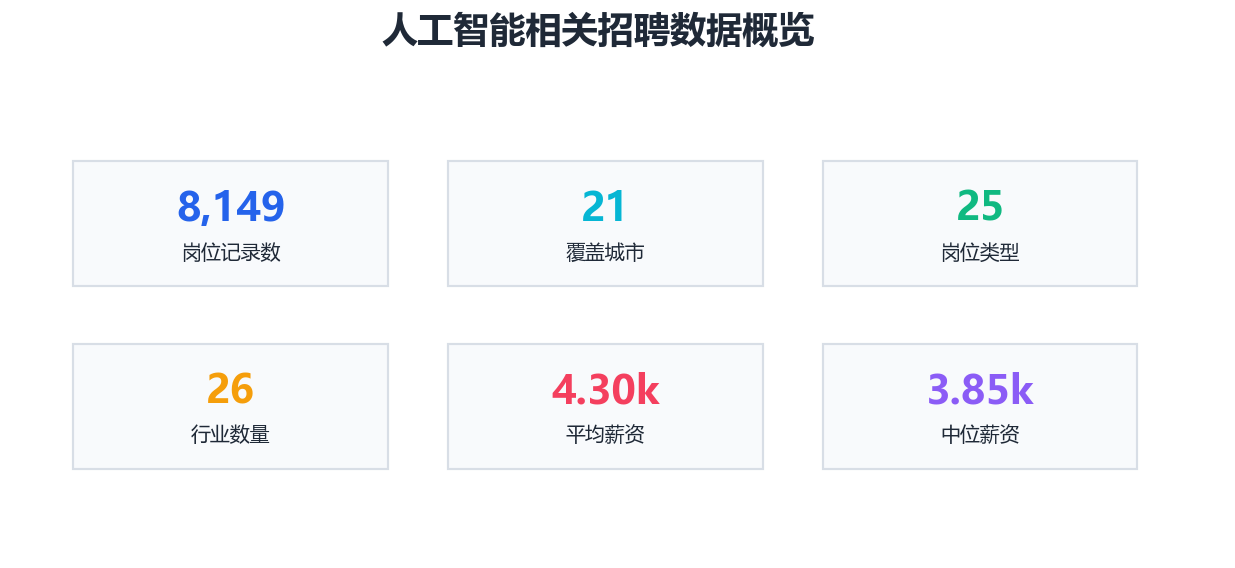

In [7]:
# 图 1：数据概览信息卡
metrics = [
    ("岗位记录数", f"{len(df):,}"),
    ("覆盖城市", f"{df['city_use'].nunique()}"),
    ("岗位类型", f"{df['search_keyword'].nunique()}"),
    ("行业数量", f"{df['industry'].nunique()}"),
    ("平均薪资", f"{df['salary_mid'].mean():.2f}k"),
    ("中位薪资", f"{df['salary_mid'].median():.2f}k"),
]

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")
fig.suptitle("人工智能相关招聘数据概览", fontsize=20, fontweight="bold", color=COLORS["dark"], y=0.98)

for i, (name, value) in enumerate(metrics):
    x = 0.05 + (i % 3) * 0.31
    y = 0.56 - (i // 3) * 0.38
    rect = Rectangle((x, y), 0.26, 0.26, linewidth=1.2,
                     edgecolor="#D8DEE6", facecolor=COLORS["light_bg"], transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x + 0.13, y + 0.16, value, ha="center", va="center",
            fontsize=22, fontweight="bold", color=PALETTE[i % len(PALETTE)], transform=ax.transAxes)
    ax.text(x + 0.13, y + 0.07, name, ha="center", va="center",
            fontsize=11, color=COLORS["dark"], transform=ax.transAxes)

save_and_show(fig, "01_数据概览信息卡.png")

## 三、城市岗位需求分析

城市是招聘可视化最直观的维度。这里先看“哪里岗位最多”，再看“岗位数量和薪资是否同步”，最后用地理气泡图和帕累托图展示岗位分布的空间集中性。

已保存：结果可视化\02_城市岗位数量排名.png


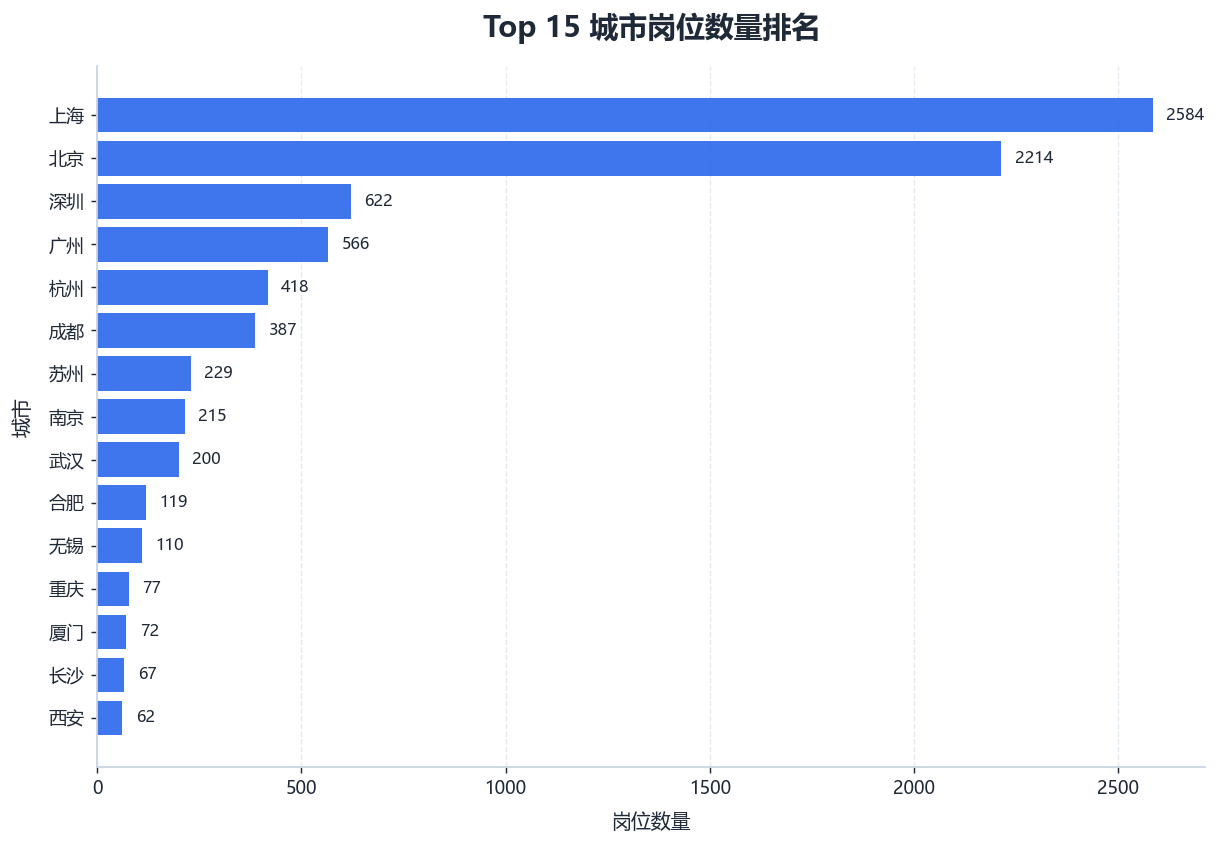

In [8]:
# 图 2：不同城市岗位数量排名
city_counts = df["city_use"].value_counts().head(TOP_N_CITY).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(city_counts.index, city_counts.values, color=COLORS["blue"], alpha=0.88)
style_ax(ax, f"Top {TOP_N_CITY} 城市岗位数量排名", "岗位数量", "城市", grid_axis="x")
add_bar_labels(ax, bars, horizontal=True)
save_and_show(fig, "02_城市岗位数量排名.png")

已保存：结果可视化\03_城市岗位数量与平均薪资对比.png


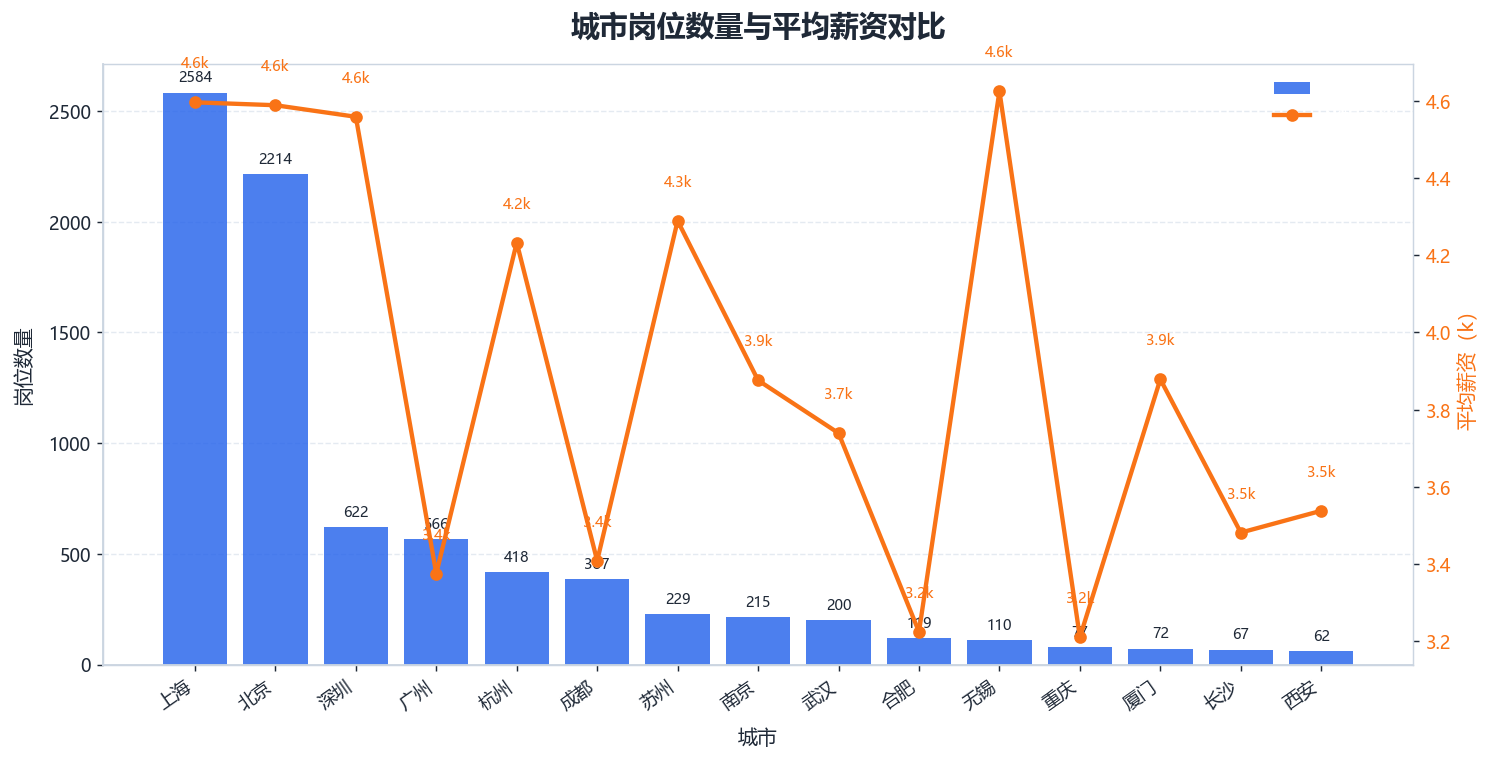

In [9]:
# 图 3：城市岗位数量与平均薪资对比
city_salary = (
    df.groupby("city_use")
      .agg(job_count=("job_title", "count"), avg_salary=("salary_mid", "mean"))
      .sort_values("job_count", ascending=False)
      .head(TOP_N_CITY)
)

fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(city_salary))
bars = ax1.bar(x, city_salary["job_count"], color=COLORS["blue"], alpha=0.82, label="岗位数量")
ax1.set_ylabel("岗位数量", color=COLORS["blue"], fontsize=11)
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.set_xticks(x)
ax1.set_xticklabels(city_salary.index, rotation=35, ha="right")
style_ax(ax1, "城市岗位数量与平均薪资对比", "城市", "岗位数量", grid_axis="y")
add_bar_labels(ax1, bars, horizontal=False, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(x, city_salary["avg_salary"], color=COLORS["orange"], marker="o", linewidth=2.4, label="平均薪资")
ax2.set_ylabel("平均薪资（k）", color=COLORS["orange"], fontsize=11)
ax2.tick_params(axis="y", labelcolor=COLORS["orange"])
for i, v in enumerate(city_salary["avg_salary"]):
    ax2.text(i, v + 0.08, f"{v:.1f}k", ha="center", va="bottom", fontsize=8, color=COLORS["orange"])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

save_and_show(fig, "03_城市岗位数量与平均薪资对比.png")

已保存：结果可视化\04_城市地理气泡图.png


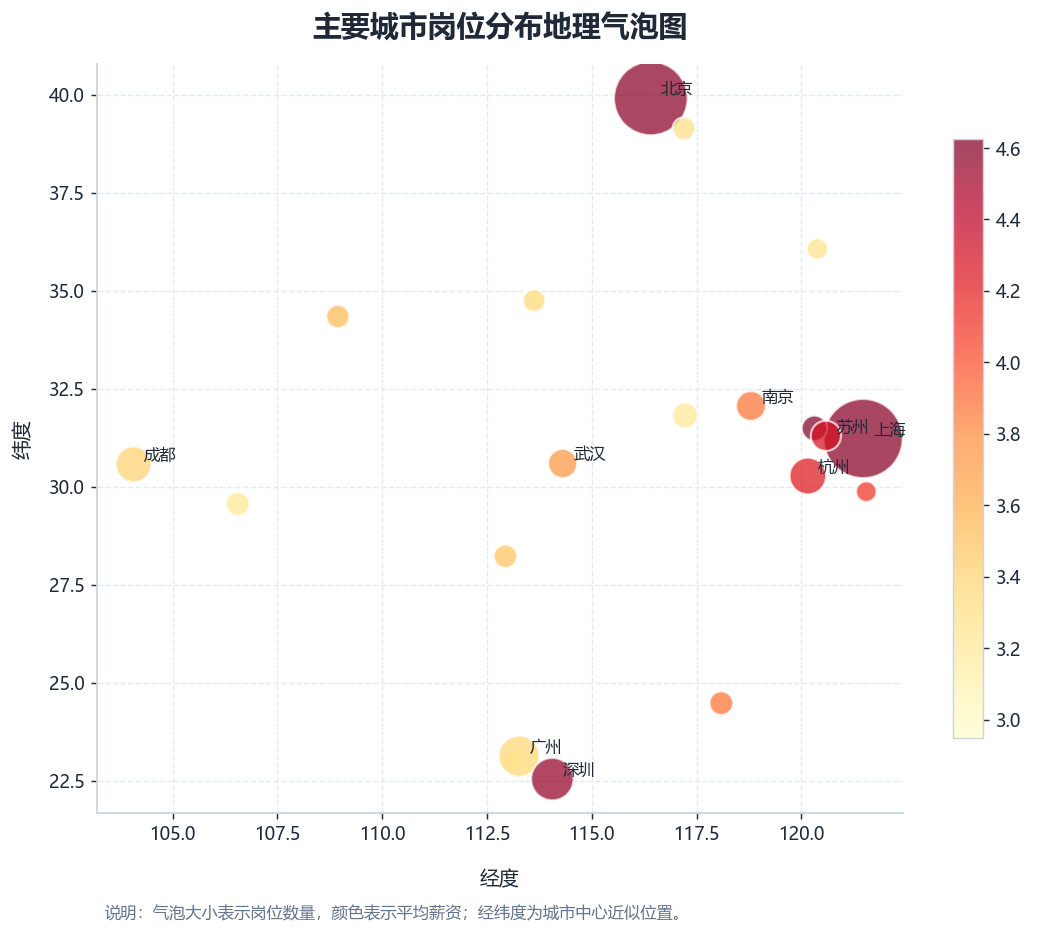

In [10]:
# 图 4：城市地理气泡图：横纵坐标为经纬度近似位置，气泡大小代表岗位数量，颜色代表平均薪资
city_geo = (
    df.groupby("city_use")
      .agg(job_count=("job_title", "count"), avg_salary=("salary_mid", "mean"))
      .reset_index()
)

city_geo["lon"] = city_geo["city_use"].map(lambda x: CITY_COORDS.get(x, (np.nan, np.nan))[0])
city_geo["lat"] = city_geo["city_use"].map(lambda x: CITY_COORDS.get(x, (np.nan, np.nan))[1])
city_geo = city_geo.dropna(subset=["lon", "lat"])

fig, ax = plt.subplots(figsize=(10, 8))
sizes = 120 + city_geo["job_count"] / city_geo["job_count"].max() * 1800

sc = ax.scatter(
    city_geo["lon"], city_geo["lat"],
    s=sizes,
    c=city_geo["avg_salary"],
    cmap="YlOrRd",
    alpha=0.72,
    edgecolor="white",
    linewidth=1.2
)

for _, row in city_geo.iterrows():
    if row["job_count"] >= city_geo["job_count"].quantile(0.55):
        ax.text(
            row["lon"] + 0.25,
            row["lat"] + 0.12,
            row["city_use"],
            fontsize=9,
            color=COLORS["dark"]
        )

style_ax(ax, "主要城市岗位分布地理气泡图", "经度", "纬度", grid_axis="both")

# 额外调一下 x 轴标题与图的距离
ax.xaxis.labelpad = 14

cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("平均薪资（k）")

# 给底部留空间，避免和 xlabel 重叠
fig.subplots_adjust(bottom=0.16)

# 说明文字下移
ax.text(
    0.01, -0.14,
    "说明：气泡大小表示岗位数量，颜色表示平均薪资；经纬度为城市中心近似位置。",
    transform=ax.transAxes,
    fontsize=9,
    color=COLORS["gray"]
)

save_and_show(fig, "04_城市地理气泡图.png")

已保存：结果可视化\05_城市岗位集中度帕累托图.png


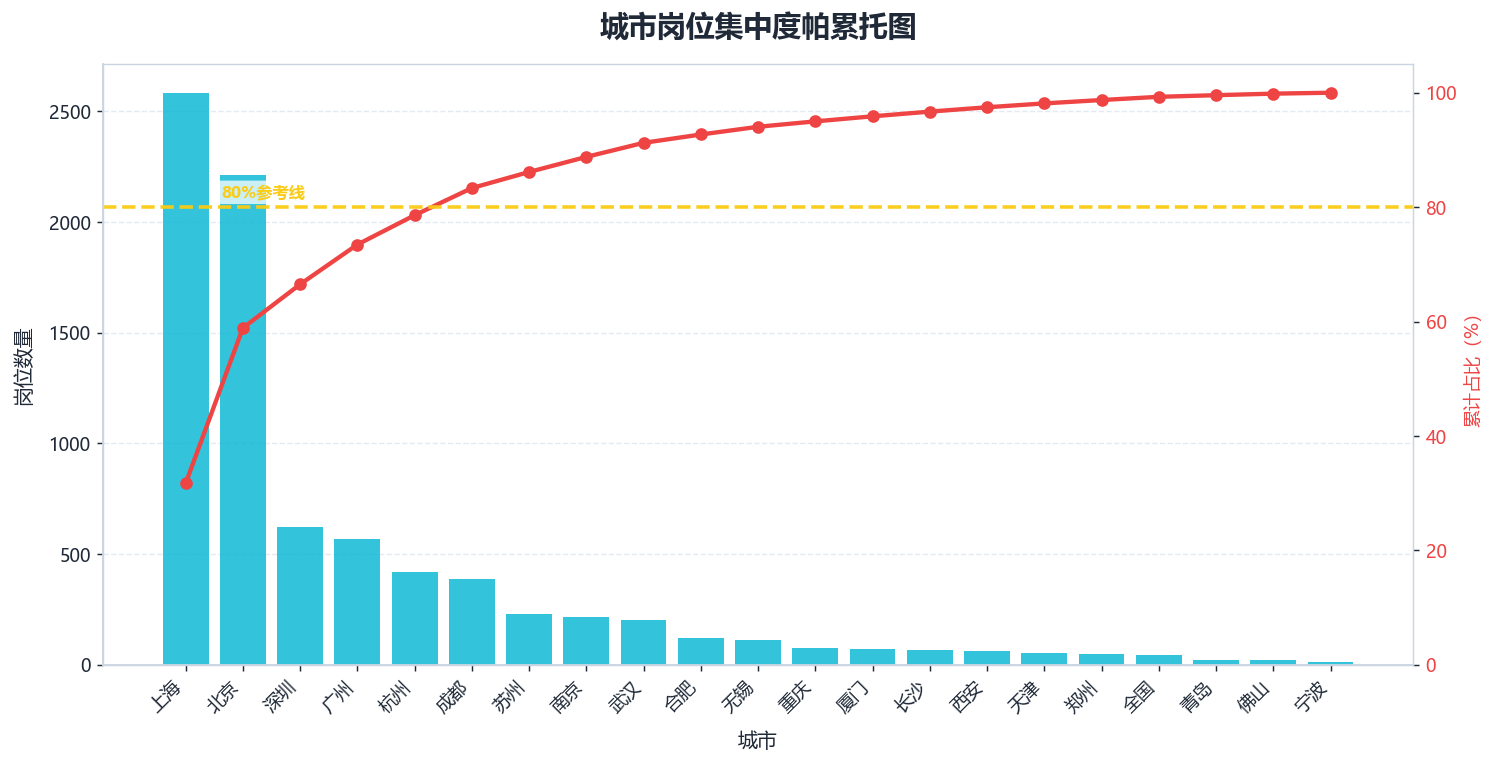

In [11]:
# 图 5：城市岗位集中度帕累托图
pareto = df["city_use"].value_counts().sort_values(ascending=False)
cum_pct = pareto.cumsum() / pareto.sum() * 100

fig, ax1 = plt.subplots(figsize=(13, 6))
x = np.arange(len(pareto))

ax1.bar(x, pareto.values, color=COLORS["cyan"], alpha=0.82, label="岗位数量")
ax1.set_ylabel("岗位数量", color=COLORS["cyan"])
ax1.tick_params(axis="y", labelcolor=COLORS["cyan"])
ax1.set_xticks(x)
ax1.set_xticklabels(pareto.index, rotation=45, ha="right")
style_ax(ax1, "城市岗位集中度帕累托图", "城市", "岗位数量", grid_axis="y")

ax2 = ax1.twinx()
ax2.plot(
    x, cum_pct.values,
    color=COLORS["red"],
    marker="o",
    linewidth=2.4,
    label="累计占比"
)
ref_color = "#FACC15"   # 鲜亮金黄色
ax2.axhline(80, color=ref_color, linestyle="--", linewidth=2.0, alpha=0.95)

ax2.text(
    len(pareto) * 0.03, 81.8,
    "80%参考线",
    color=ref_color,
    fontsize=9,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, boxstyle="round,pad=0.2")
)
ax2.set_ylim(0, 105)
ax2.set_ylabel("累计占比（%）", color=COLORS["red"])
ax2.tick_params(axis="y", labelcolor=COLORS["red"])

save_and_show(fig, "05_城市岗位集中度帕累托图.png")

## 四、薪资水平分析

薪资分析先看整体分布，再比较不同城市、不同岗位类型的薪资差异。  
直方图适合看总体集中在哪个区间；箱线图适合比较城市或岗位之间的薪资离散程度和异常值。

已保存：结果可视化\06_薪资整体分布直方图.png


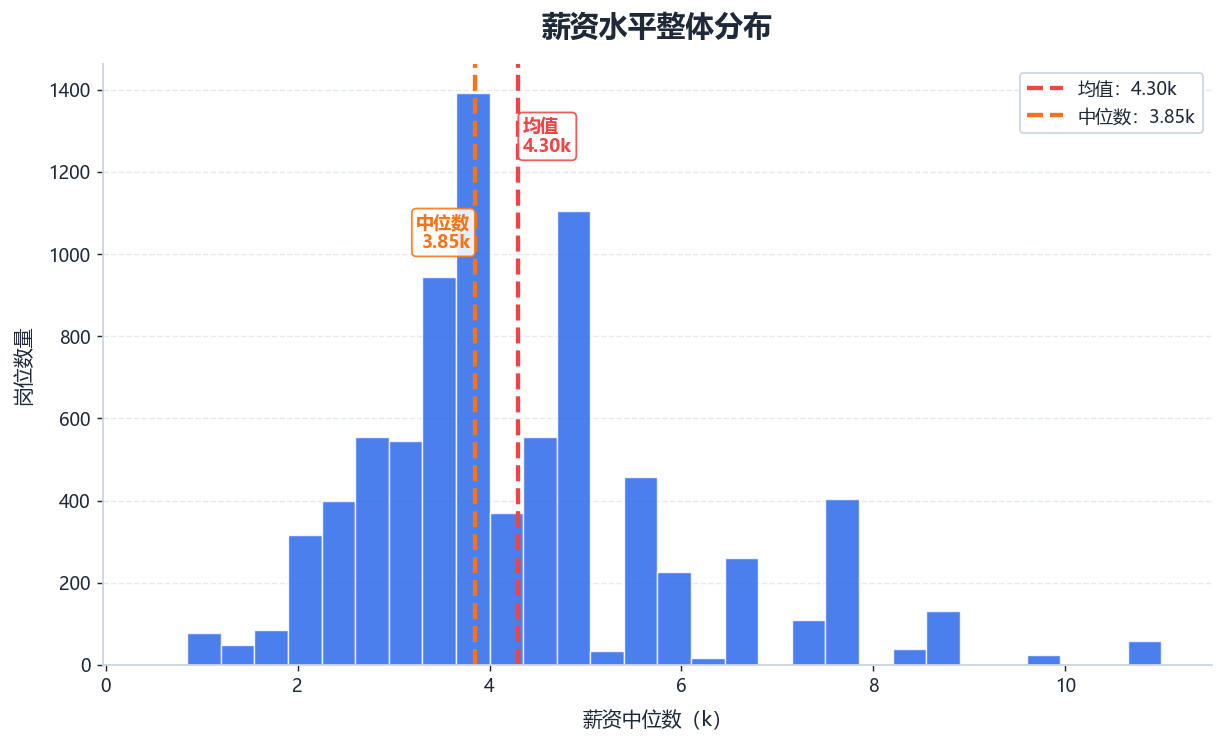

In [12]:
# 图 6：薪资整体分布直方图
salary = df["salary_mid"].dropna()
mean_salary = salary.mean()
median_salary = salary.median()
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    salary,
    bins=30,
    color=COLORS["blue"],
    alpha=0.82,
    edgecolor="white",
    linewidth=0.8
)
mean_line = ax.axvline(
    mean_salary,
    color=COLORS["red"],
    linestyle="--",
    linewidth=2.4,
    label=f"均值：{mean_salary:.2f}k"
)
median_line = ax.axvline(
    median_salary,
    color=COLORS["orange"],
    linestyle="--",
    linewidth=2.4,
    label=f"中位数：{median_salary:.2f}k"
)
style_ax(ax, "薪资水平整体分布", "薪资中位数（k）", "岗位数量", grid_axis="y")
ymax = ax.get_ylim()[1]

ax.text(
    mean_salary + 0.05,
    ymax * 0.88,
    f"均值\n{mean_salary:.2f}k",
    color=COLORS["red"],
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="center",
    bbox=dict(facecolor="white", edgecolor=COLORS["red"], alpha=0.88, boxstyle="round,pad=0.25")
)
ax.text(
    median_salary - 0.05,
    ymax * 0.72,
    f"中位数\n{median_salary:.2f}k",
    color=COLORS["orange"],
    fontsize=10,
    fontweight="bold",
    ha="right",
    va="center",
    bbox=dict(facecolor="white", edgecolor=COLORS["orange"], alpha=0.88, boxstyle="round,pad=0.25")
)
legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.95,
    fontsize=10
)
for text in legend.get_texts():
    text.set_color(COLORS["dark"])

save_and_show(fig, "06_薪资整体分布直方图.png")

已保存：结果可视化\07_薪资档位占比甜甜圈图.png


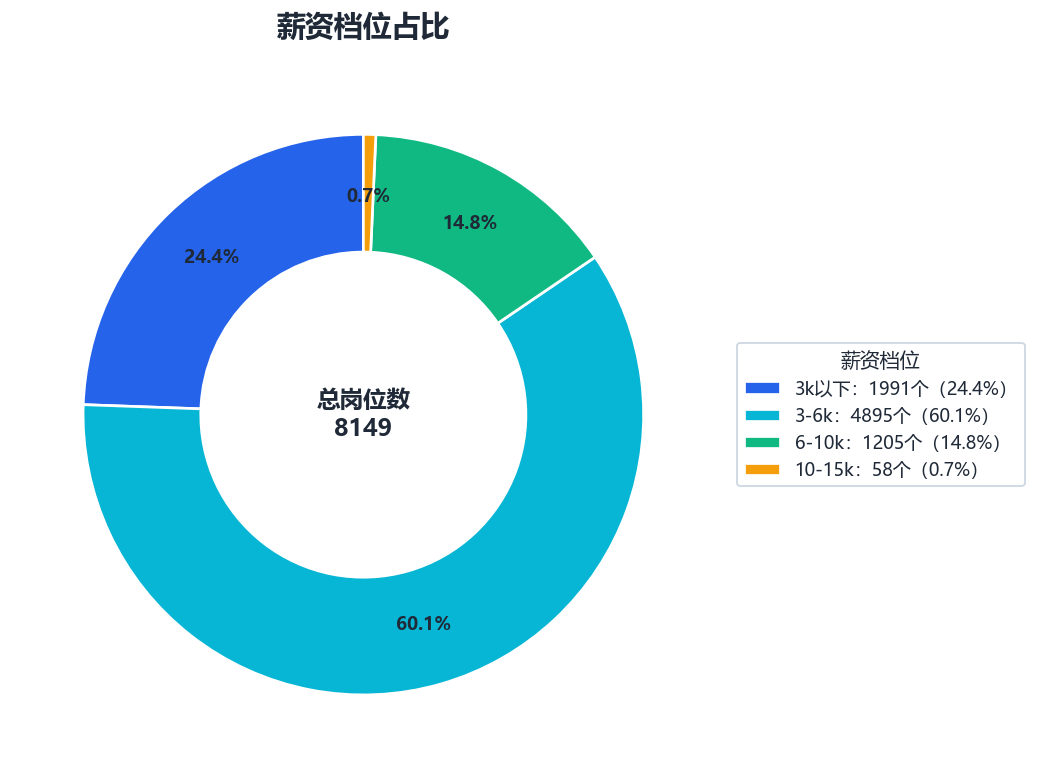

In [13]:
# 图 7：薪资档位占比甜甜圈图
salary_tier = df["salary_tier"].value_counts()
ordered_tiers = [x for x in SALARY_TIER_ORDER if x in salary_tier.index] + [x for x in salary_tier.index if x not in SALARY_TIER_ORDER]
salary_tier = salary_tier.loc[ordered_tiers]
fig, ax = plt.subplots(figsize=(10, 7))
colors = PALETTE[:len(salary_tier)]
wedges, texts, autotexts = ax.pie(
    salary_tier.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.5)
)

for t in autotexts:
    t.set_fontsize(10)
    t.set_color(COLORS["dark"])
    t.set_fontweight("bold")

ax.text(
    0, 0,
    f"总岗位数\n{salary_tier.sum()}",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color=COLORS["dark"]
)
total = salary_tier.sum()
legend_labels = [
    f"{tier}：{count}个（{count/total*100:.1f}%）"
    for tier, count in zip(salary_tier.index, salary_tier.values)
]
legend = ax.legend(
    wedges,
    legend_labels,
    title="薪资档位",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.95,
    fontsize=10,
    title_fontsize=11
)
for text in legend.get_texts():
    text.set_color(COLORS["dark"])
legend.get_title().set_color(COLORS["dark"])

ax.set_title("薪资档位占比", fontsize=16, fontweight="bold", color=COLORS["dark"], pad=16)
fig.subplots_adjust(right=0.80)
save_and_show(fig, "07_薪资档位占比甜甜圈图.png")

已保存：结果可视化\08_主要城市薪资分布箱线图.png


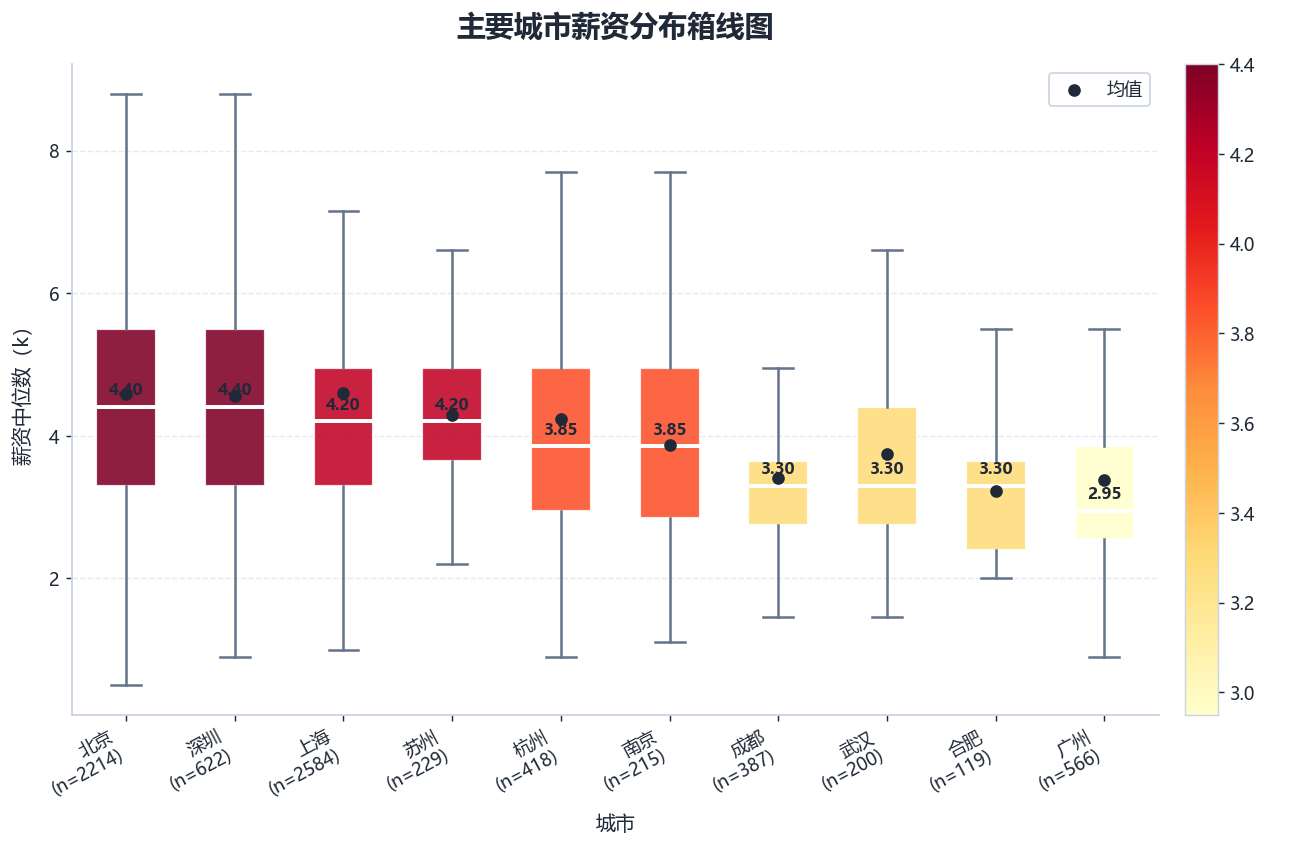

In [14]:
# 图 8：主要城市薪资分布箱线图（优化版：颜色表示该城市薪资中位数）
city_top = df["city_use"].value_counts().head(10).index

# 构造城市薪资数据
city_salary_data = []
for c in city_top:
    s = df.loc[df["city_use"] == c, "salary_mid"].dropna()
    city_salary_data.append({
        "city": c,
        "salary": s,
        "median": s.median(),
        "mean": s.mean(),
        "count": len(s)
    })

city_salary_data = sorted(city_salary_data, key=lambda x: x["median"], reverse=True)

labels = [f'{d["city"]}\n(n={d["count"]})' for d in city_salary_data]
box_data = [d["salary"] for d in city_salary_data]
medians = [d["median"] for d in city_salary_data]
means = [d["mean"] for d in city_salary_data]
fig, ax = plt.subplots(figsize=(13, 6.5))
bp = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=labels,
    showfliers=False,
    widths=0.55,
    medianprops=dict(color="white", linewidth=2.2),
    whiskerprops=dict(color=COLORS["gray"], linewidth=1.4),
    capprops=dict(color=COLORS["gray"], linewidth=1.4),
    boxprops=dict(edgecolor="white", linewidth=1.2)
)
norm = plt.Normalize(min(medians), max(medians))
cmap = plt.cm.YlOrRd
box_colors = [cmap(norm(m)) for m in medians]

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.88)

x = np.arange(1, len(means) + 1)
ax.scatter(
    x, means,
    color=COLORS["dark"],
    s=36,
    zorder=3,
    label="均值"
)
for i, med in enumerate(medians, start=1):
    ax.text(
        i, med + 0.12,
        f"{med:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=COLORS["dark"],
        fontweight="bold"
    )

style_ax(ax, "主要城市薪资分布箱线图", "城市", "薪资中位数（k）", grid_axis="y")
plt.setp(ax.get_xticklabels(), rotation=28, ha="right")

legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.95
)
for text in legend.get_texts():
    text.set_color(COLORS["dark"])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("城市薪资中位数（k）")

save_and_show(fig, "08_主要城市薪资分布箱线图.png")

已保存：结果可视化\09_主要岗位类型薪资分布箱线图.png


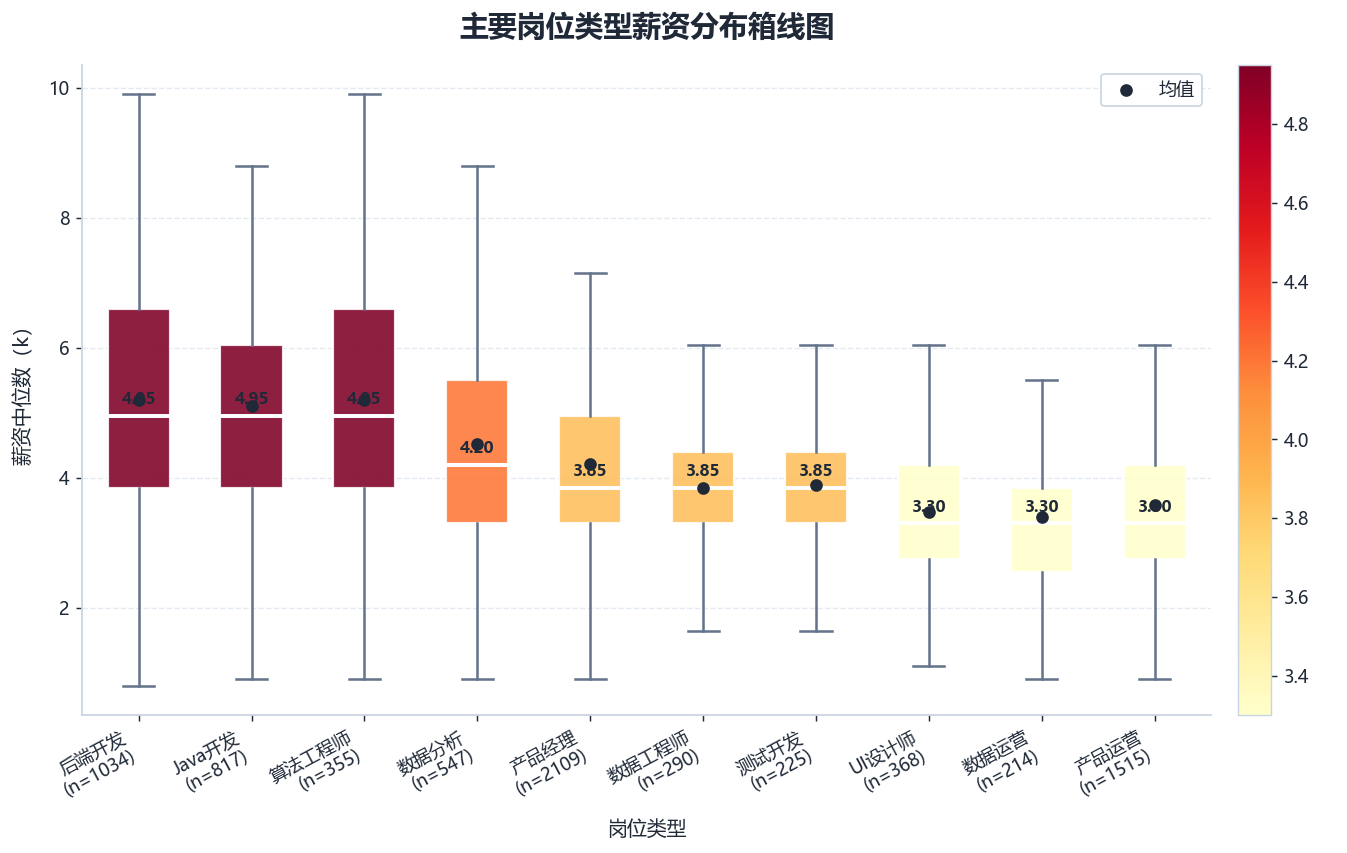

In [15]:
# 图 9：主要岗位类型薪资分布箱线图（优化版：颜色表示该岗位类型薪资中位数）
job_top = df["search_keyword"].value_counts().head(10).index

# 构造岗位类型薪资数据
job_salary_data = []
for j in job_top:
    s = df.loc[df["search_keyword"] == j, "salary_mid"].dropna()
    job_salary_data.append({
        "job": j,
        "salary": s,
        "median": s.median(),
        "mean": s.mean(),
        "count": len(s)
    })

job_salary_data = sorted(job_salary_data, key=lambda x: x["median"], reverse=True)

labels = [f'{shorten_label(d["job"], 9)}\n(n={d["count"]})' for d in job_salary_data]
box_data = [d["salary"] for d in job_salary_data]
medians = [d["median"] for d in job_salary_data]
means = [d["mean"] for d in job_salary_data]

fig, ax = plt.subplots(figsize=(13.5, 6.5))

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=labels,
    showfliers=False,
    widths=0.55,
    medianprops=dict(color="white", linewidth=2.2),
    whiskerprops=dict(color=COLORS["gray"], linewidth=1.4),
    capprops=dict(color=COLORS["gray"], linewidth=1.4),
    boxprops=dict(edgecolor="white", linewidth=1.2)
)

# 用中位数映射颜色：中位数越高，颜色越暖/越深
norm = plt.Normalize(min(medians), max(medians))
cmap = plt.cm.YlOrRd
box_colors = [cmap(norm(m)) for m in medians]

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.88)

x = np.arange(1, len(means) + 1)
ax.scatter(
    x, means,
    color=COLORS["dark"],
    s=36,
    zorder=3,
    label="均值"
)

# 标注中位数数值
for i, med in enumerate(medians, start=1):
    ax.text(
        i, med + 0.12,
        f"{med:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=COLORS["dark"],
        fontweight="bold"
    )

style_ax(ax, "主要岗位类型薪资分布箱线图", "岗位类型", "薪资中位数（k）", grid_axis="y")
plt.setp(ax.get_xticklabels(), rotation=28, ha="right")
legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.95
)
for text in legend.get_texts():
    text.set_color(COLORS["dark"])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("岗位类型薪资中位数（k）")

save_and_show(fig, "09_主要岗位类型薪资分布箱线图.png")

## 五、学历、经验、公司规模与行业分析

这一层开始分析岗位要求。  
先看学历结构，再看学历和薪资是否存在关联；如果经验字段本身缺乏区分度，就只做分布展示，不强行解释经验与薪资关系。

已保存：结果可视化\10_学历要求占比.png


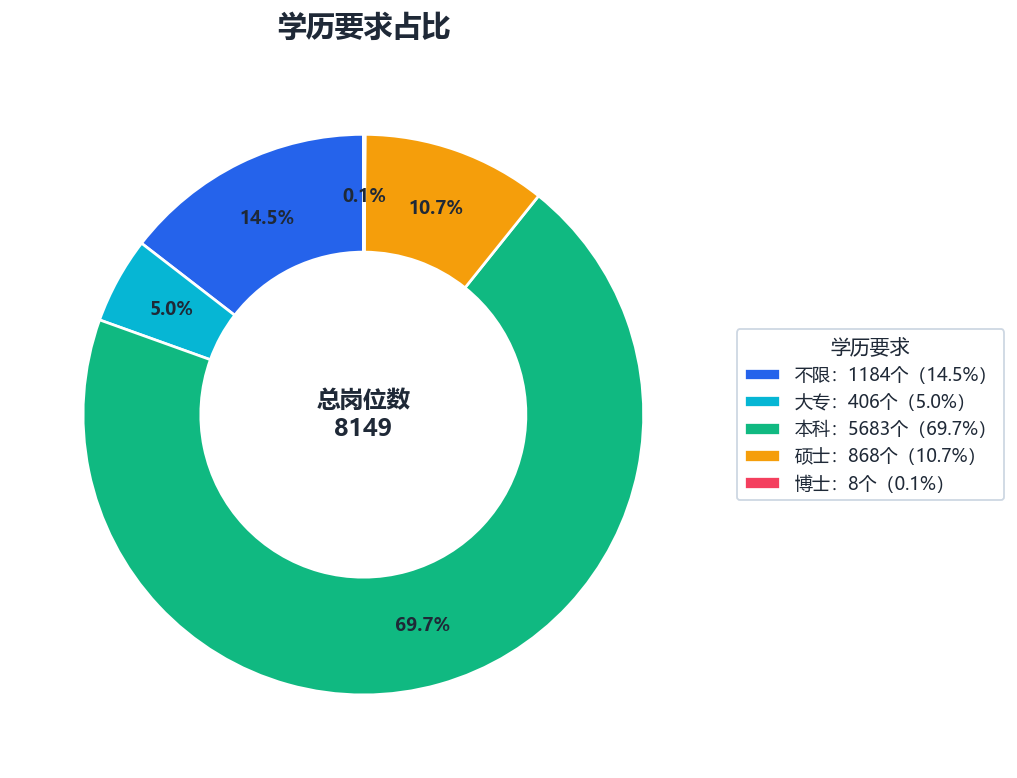

In [16]:
# 图 10：学历要求占比甜甜圈图（优化版：右侧图例写清楚每一块含义）
edu_counts = df["education"].value_counts()
edu_order = [x for x in EDU_ORDER if x in edu_counts.index] + [x for x in edu_counts.index if x not in EDU_ORDER]
edu_counts = edu_counts.loc[edu_order]
fig, ax = plt.subplots(figsize=(10, 7))
colors = PALETTE[:len(edu_counts)]
wedges, texts, autotexts = ax.pie(
    edu_counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color(COLORS["dark"])
    t.set_fontweight("bold")
ax.text(
    0, 0,
    f"总岗位数\n{edu_counts.sum()}",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    color=COLORS["dark"]
)
total = edu_counts.sum()
legend_labels = [
    f"{edu}：{count}个（{count/total*100:.1f}%）"
    for edu, count in zip(edu_counts.index, edu_counts.values)
]
legend = ax.legend(
    wedges,
    legend_labels,
    title="学历要求",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.95,
    fontsize=10,
    title_fontsize=11
)

for text in legend.get_texts():
    text.set_color(COLORS["dark"])
legend.get_title().set_color(COLORS["dark"])

ax.set_title("学历要求占比", fontsize=16, fontweight="bold", color=COLORS["dark"], pad=16)

fig.subplots_adjust(right=0.80)

save_and_show(fig, "10_学历要求占比.png")

已保存：结果可视化\11_学历要求与平均薪资.png


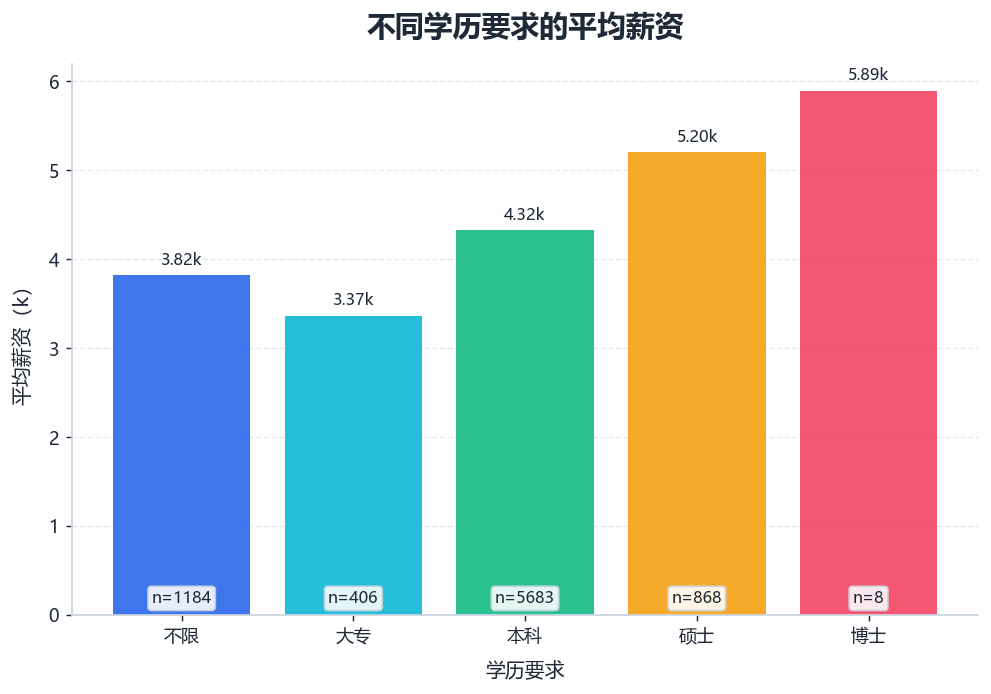

In [17]:
# 图 11：学历要求与平均薪资关系
edu_salary = (
    df.groupby("education")
      .agg(job_count=("job_title", "count"), avg_salary=("salary_mid", "mean"))
)

edu_salary = edu_salary.loc[
    [x for x in EDU_ORDER if x in edu_salary.index] +
    [x for x in edu_salary.index if x not in EDU_ORDER]
]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    edu_salary.index,
    edu_salary["avg_salary"],
    color=PALETTE[:len(edu_salary)],
    alpha=0.88
)

style_ax(ax, "不同学历要求的平均薪资", "学历要求", "平均薪资（k）", grid_axis="y")
add_bar_labels(ax, bars, fmt="{:.2f}k")

ymax = ax.get_ylim()[1]
y_pos = ymax * 0.03

for i, count in enumerate(edu_salary["job_count"]):
    ax.text(
        i,
        y_pos,
        f"n={count}",
        ha="center",
        va="center",
        fontsize=9,
        color=COLORS["dark"],
        bbox=dict(
            facecolor="white",
            edgecolor=COLORS["light_gray"],
            alpha=0.88,
            boxstyle="round,pad=0.22"
        )
    )

save_and_show(fig, "11_学历要求与平均薪资.png")

已保存：结果可视化\12_公司规模与岗位数量平均薪资.png


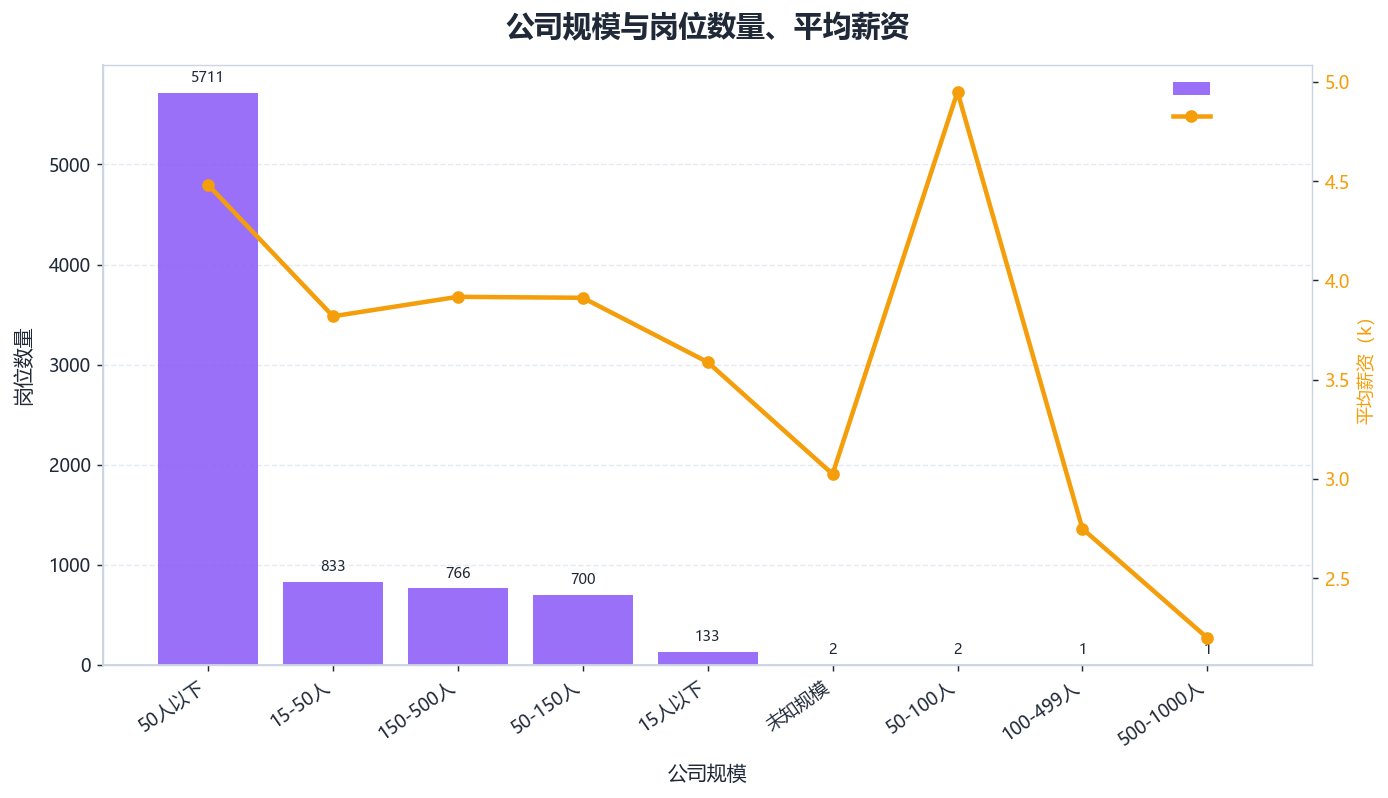

In [18]:
# 图 12：公司规模与岗位数量、平均薪资
if not is_meaningful_category(df["company_size_use"], min_unique=2, max_top_ratio=0.995):
    skip_plot("company_size_use 字段区分度较低，不适合单独作图。")
else:
    size_stats = (
        df.groupby("company_size_use")
          .agg(job_count=("job_title", "count"), avg_salary=("salary_mid", "mean"))
          .sort_values("job_count", ascending=False)
    )

    fig, ax1 = plt.subplots(figsize=(12, 6))
    x = np.arange(len(size_stats))
    bars = ax1.bar(x, size_stats["job_count"], color=COLORS["purple"], alpha=0.88, label="岗位数量")
    ax1.set_xticks(x)
    ax1.set_xticklabels(size_stats.index, rotation=35, ha="right")
    style_ax(ax1, "公司规模与岗位数量、平均薪资", "公司规模", "岗位数量", grid_axis="y")
    add_bar_labels(ax1, bars, horizontal=False, fontsize=8)

    ax2 = ax1.twinx()
    ax2.plot(x, size_stats["avg_salary"], color=COLORS["amber"], marker="o", markersize=6, linewidth=2.5, label="平均薪资")
    ax2.set_ylabel("平均薪资（k）", color=COLORS["amber"])
    ax2.tick_params(axis="y", labelcolor=COLORS["amber"])

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)
    save_and_show(fig, "12_公司规模与岗位数量平均薪资.png")


已保存：结果可视化\13_行业平均薪资排名.png


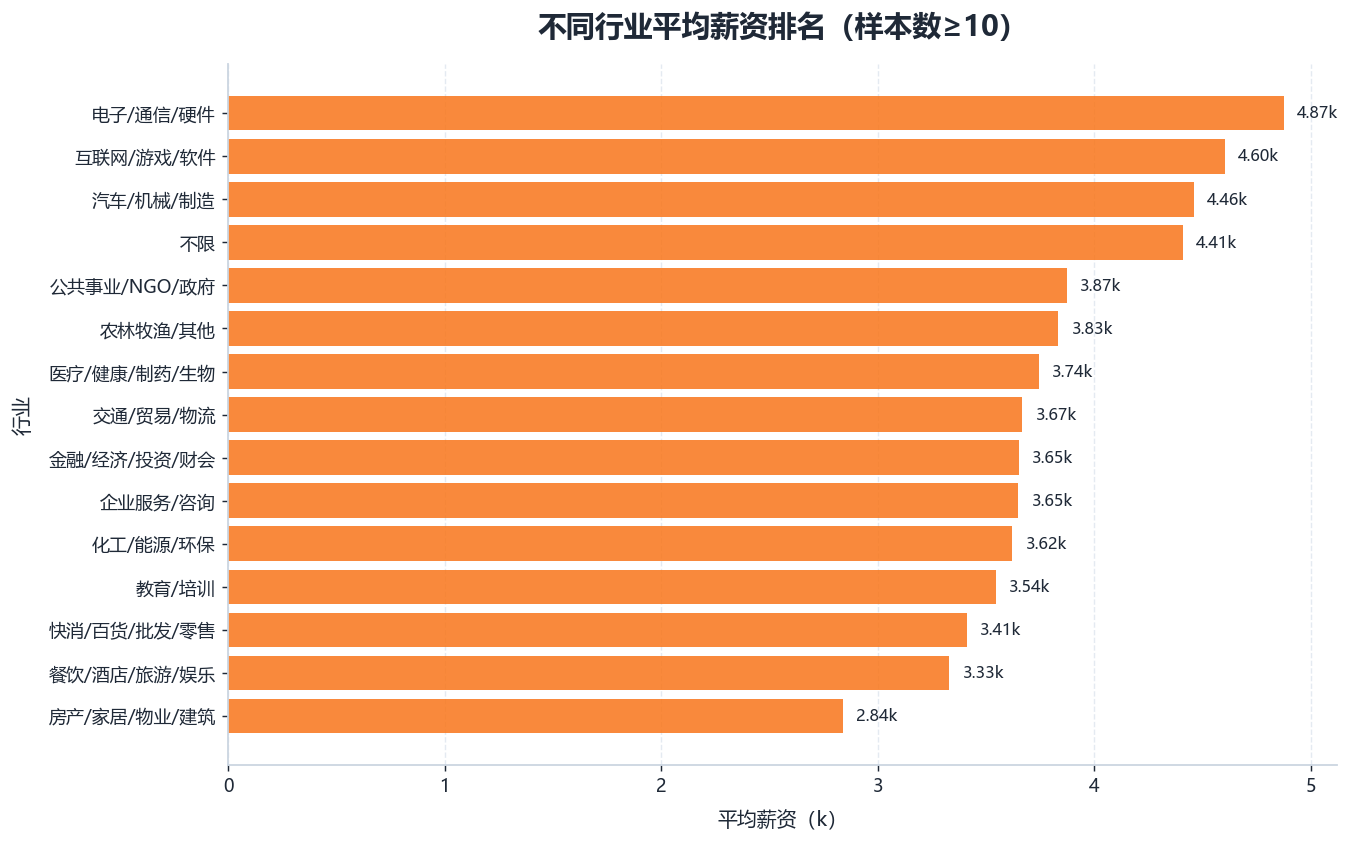

In [19]:
# 图 13：不同行业平均薪资排名
industry_salary = (
    df.groupby("industry")
      .agg(job_count=("job_title", "count"), avg_salary=("salary_mid", "mean"))
      .query("job_count >= 10")
      .sort_values("avg_salary", ascending=False)
      .head(TOP_N_INDUSTRY)
      .sort_values("avg_salary")
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(industry_salary.index.map(lambda x: shorten_label(x, 14)), industry_salary["avg_salary"],
               color=COLORS["orange"], alpha=0.84)
style_ax(ax, "不同行业平均薪资排名（样本数≥10）", "平均薪资（k）", "行业", grid_axis="x")
add_bar_labels(ax, bars, fmt="{:.2f}k", horizontal=True)
save_and_show(fig, "13_行业平均薪资排名.png")

## 六、岗位类型分析

岗位类型是本题的核心。这里依次分析：哪些岗位需求最多、哪些岗位薪资更高、岗位需求量与薪资是否同步、不同城市的岗位类型结构是否不同。

已保存：结果可视化\14_岗位类型需求量排名.png


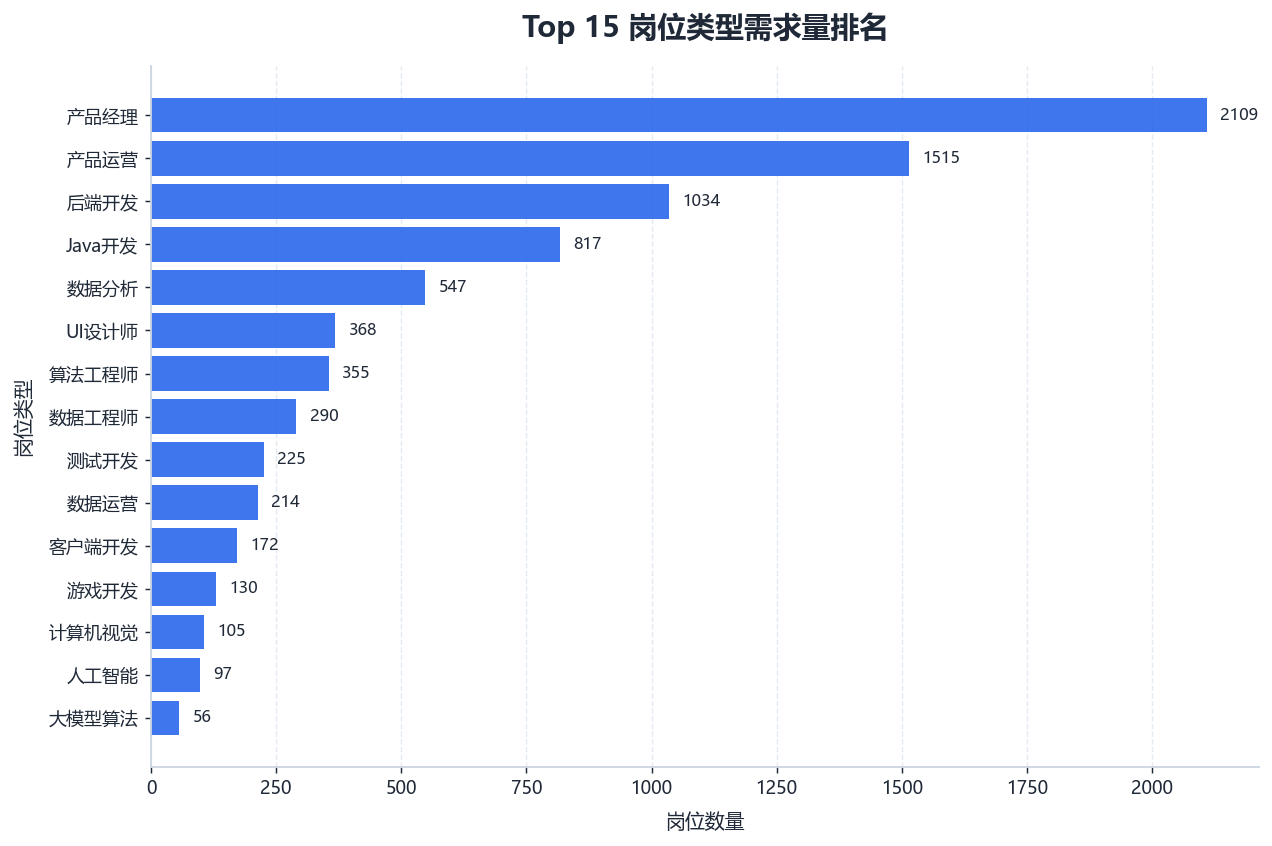

In [20]:
# 图 14：岗位类型需求量排名
job_counts = df["search_keyword"].value_counts().head(TOP_N_JOB).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(job_counts.index, job_counts.values, color=COLORS["blue"], alpha=0.88)
style_ax(ax, f"Top {TOP_N_JOB} 岗位类型需求量排名", "岗位数量", "岗位类型", grid_axis="x")
add_bar_labels(ax, bars, horizontal=True)
save_and_show(fig, "14_岗位类型需求量排名.png")

已保存：结果可视化\15_岗位类型平均薪资排名.png


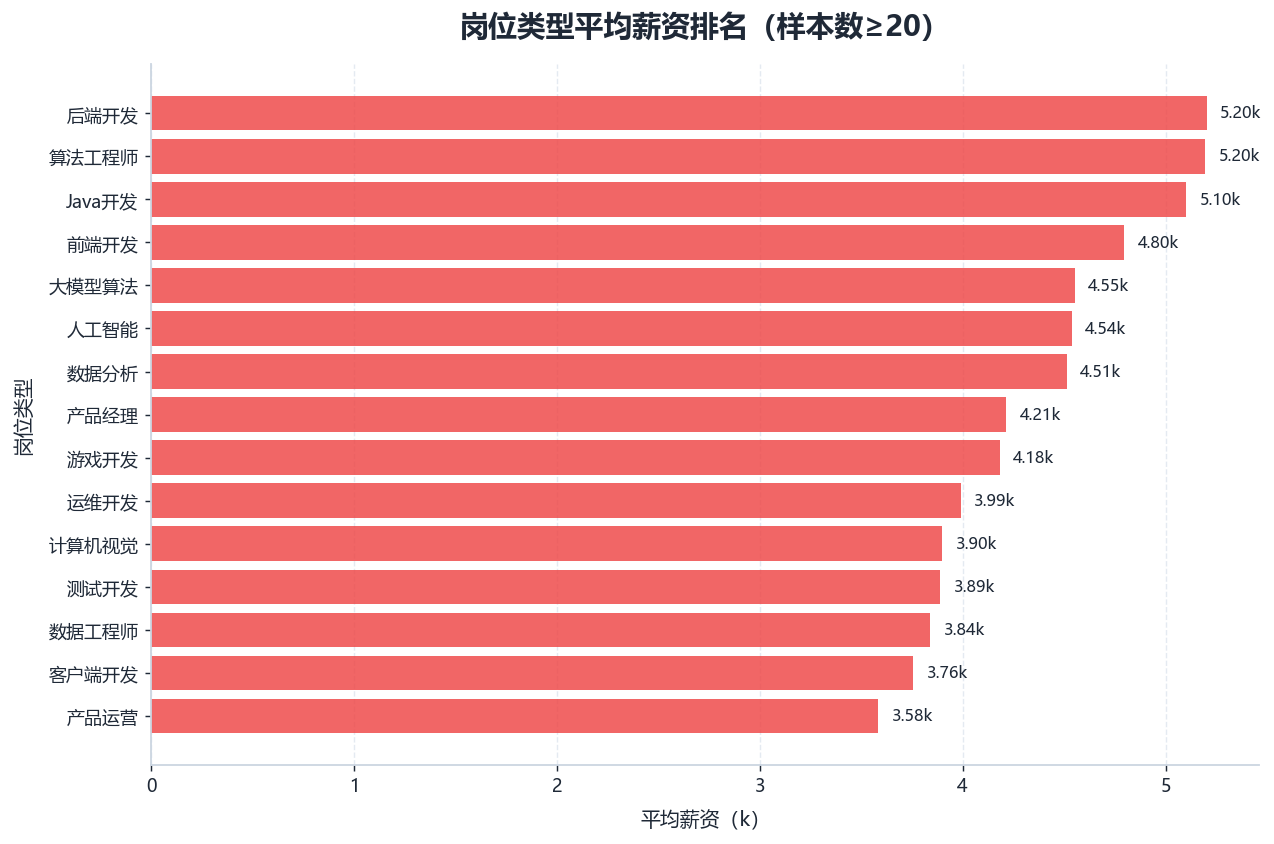

In [21]:
# 图 15：岗位类型平均薪资排名
job_salary = (
    df.groupby("search_keyword")
      .agg(job_count=("job_title", "count"), avg_salary=("salary_mid", "mean"), avg_edu=("edu_score", "mean"))
      .query("job_count >= 20")
      .sort_values("avg_salary", ascending=False)
      .head(TOP_N_JOB)
      .sort_values("avg_salary")
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(job_salary.index.map(lambda x: shorten_label(x, 14)), job_salary["avg_salary"],
               color=COLORS["red"], alpha=0.82)
style_ax(ax, "岗位类型平均薪资排名（样本数≥20）", "平均薪资（k）", "岗位类型", grid_axis="x")
add_bar_labels(ax, bars, fmt="{:.2f}k", horizontal=True)
save_and_show(fig, "15_岗位类型平均薪资排名.png")

已保存：结果可视化\16_岗位类型需求薪资学历气泡图.png


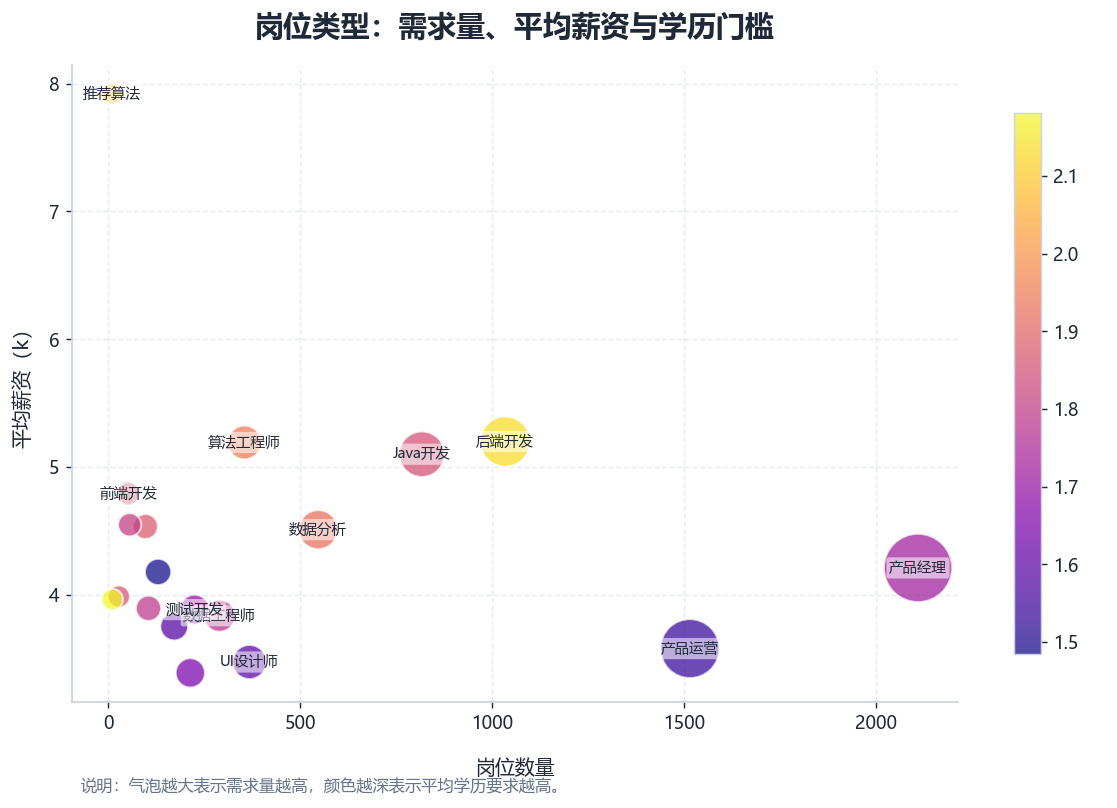

In [22]:
# 图 16：岗位类型需求量-薪资-学历门槛气泡图（优化版）
job_bubble = (
    df.groupby("search_keyword")
      .agg(
          job_count=("job_title", "count"),
          avg_salary=("salary_mid", "mean"),
          avg_edu=("edu_score", "mean")
      )
      .query("job_count >= 10")
      .sort_values("job_count", ascending=False)
      .head(20)
      .reset_index()
)
fig, ax = plt.subplots(figsize=(11, 7))
sizes = 130 + job_bubble["job_count"] / job_bubble["job_count"].max() * 1300
sc = ax.scatter(
    job_bubble["job_count"],
    job_bubble["avg_salary"],
    s=sizes,
    c=job_bubble["avg_edu"],
    cmap="plasma",
    alpha=0.72,
    edgecolor="white",
    linewidth=1.1
)

for _, row in job_bubble.iterrows():
    if (
        row["job_count"] >= job_bubble["job_count"].quantile(0.55)
        or row["avg_salary"] >= job_bubble["avg_salary"].quantile(0.75)
    ):
        ax.text(
            row["job_count"],
            row["avg_salary"],
            shorten_label(row["search_keyword"], 8),
            ha="center",
            va="center",
            fontsize=8,
            color=COLORS["dark"],
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.55,
                boxstyle="round,pad=0.18"
            ),
            zorder=4
        )

style_ax(ax, "岗位类型：需求量、平均薪资与学历门槛", "岗位数量", "平均薪资（k）", grid_axis="both")

ax.xaxis.labelpad = 14
cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("平均学历分数")
fig.subplots_adjust(bottom=0.18)
ax.text(
    0.01, -0.14,
    "说明：气泡越大表示需求量越高，颜色越深表示平均学历要求越高。",
    transform=ax.transAxes,
    fontsize=9,
    color=COLORS["gray"]
)
save_and_show(fig, "16_岗位类型需求薪资学历气泡图.png")

已保存：结果可视化\17_城市岗位类型结构堆叠图.png


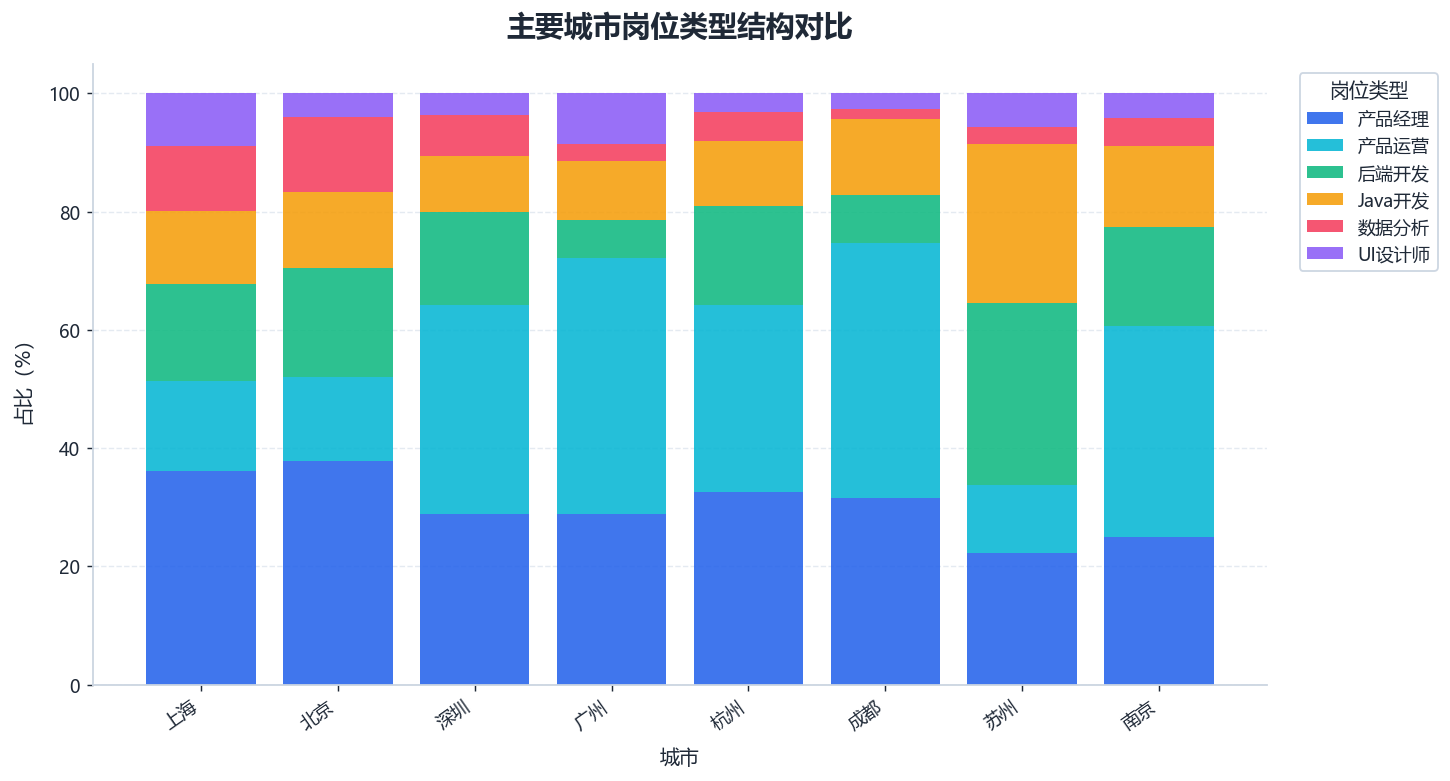

In [23]:
# 图 17：不同城市岗位类型结构百分比堆叠柱状图（优化图例版）
city_top = df["city_use"].value_counts().head(8).index
job_top = df["search_keyword"].value_counts().head(6).index

stack_df = pd.crosstab(df["city_use"], df["search_keyword"])
stack_df = stack_df.loc[city_top, job_top]
stack_pct = stack_df.div(stack_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6.2))
bottom = np.zeros(len(stack_pct))
for i, col in enumerate(stack_pct.columns):
    ax.bar(
        stack_pct.index,
        stack_pct[col],
        bottom=bottom,
        color=PALETTE[i % len(PALETTE)],
        label=shorten_label(col, 10),
        alpha=0.88
    )
    bottom += stack_pct[col].values

style_ax(ax, "主要城市岗位类型结构对比", "城市", "占比（%）", grid_axis="y")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.subplots_adjust(right=0.82)
legend = ax.legend(
    title="岗位类型",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.96,
    fontsize=10,
    title_fontsize=11
)
for text in legend.get_texts():
    text.set_color(COLORS["dark"])
legend.get_title().set_color(COLORS["dark"])
save_and_show(fig, "17_城市岗位类型结构堆叠图.png")

## 七、技能关键词分析

技能关键词用于回答“招聘市场最看重哪些能力”。  
这里从岗位文本中匹配技能词，先看高频技能，再看技能之间的共现关系。

In [24]:
# 技能关键词频率表
skill_freq = pd.Series([s for skills in df["skills"] for s in skills]).value_counts()
skill_table = skill_freq.reset_index()
skill_table.columns = ["技能关键词", "出现次数"]
display(skill_table.head(30))

,技能关键词,出现次数
0,产品,3759
1,运营,2781
2,后端,1139
3,算法,841
4,Java,817
5,数据分析,568
6,测试,414
7,UI,368
8,数据工程,308
9,客户端,194


已保存：结果可视化\18_技能关键词频率条形图.png


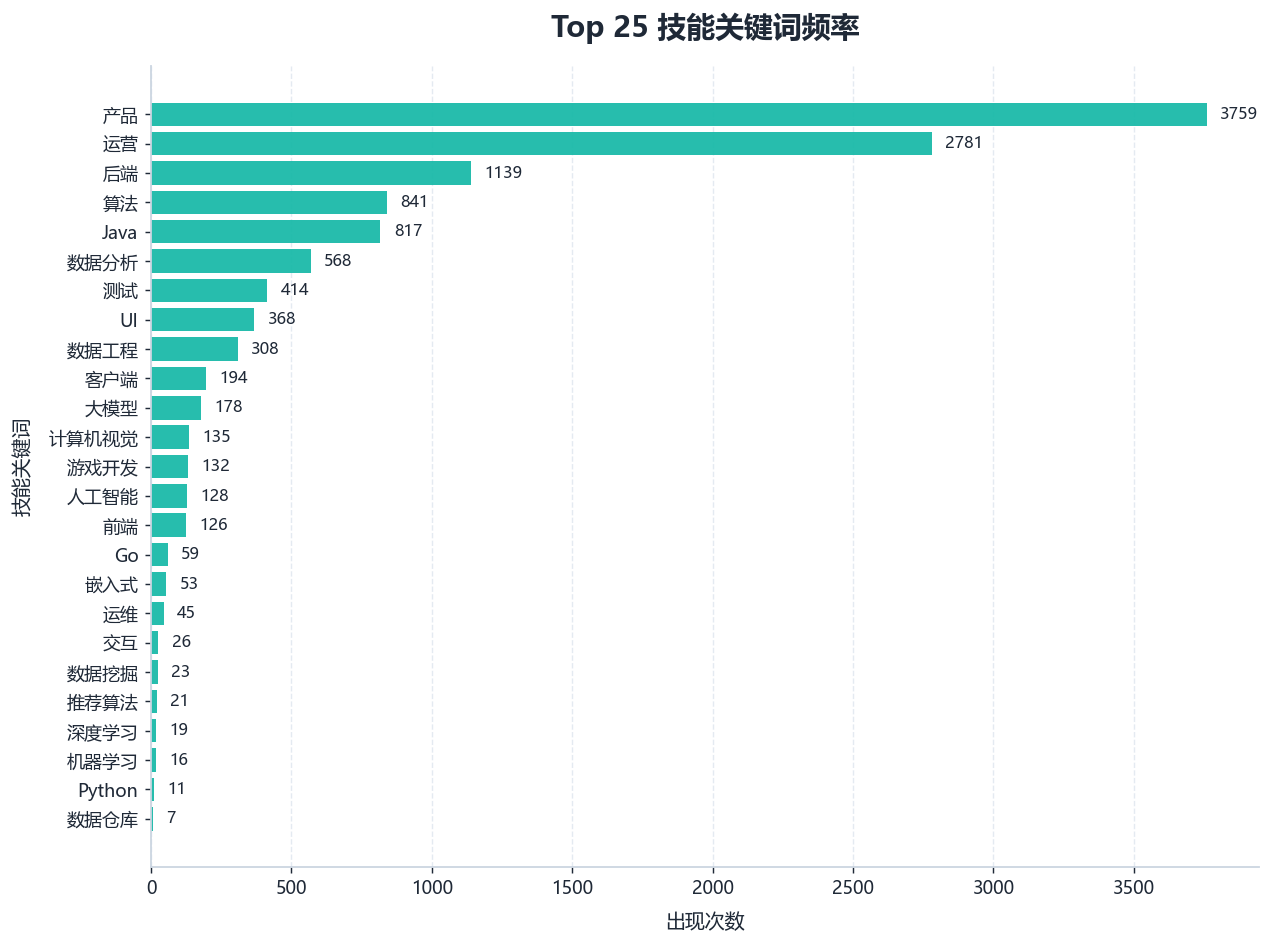

In [25]:
# 图 18：技能关键词频率条形图
skill_top = skill_freq.head(TOP_N_SKILL).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(skill_top.index, skill_top.values, color=COLORS["teal"], alpha=0.92)
style_ax(ax, f"Top {TOP_N_SKILL} 技能关键词频率", "出现次数", "技能关键词", grid_axis="x")
add_bar_labels(ax, bars, horizontal=True)
save_and_show(fig, "18_技能关键词频率条形图.png")

已保存：结果可视化\19_技能关键词词云图.png


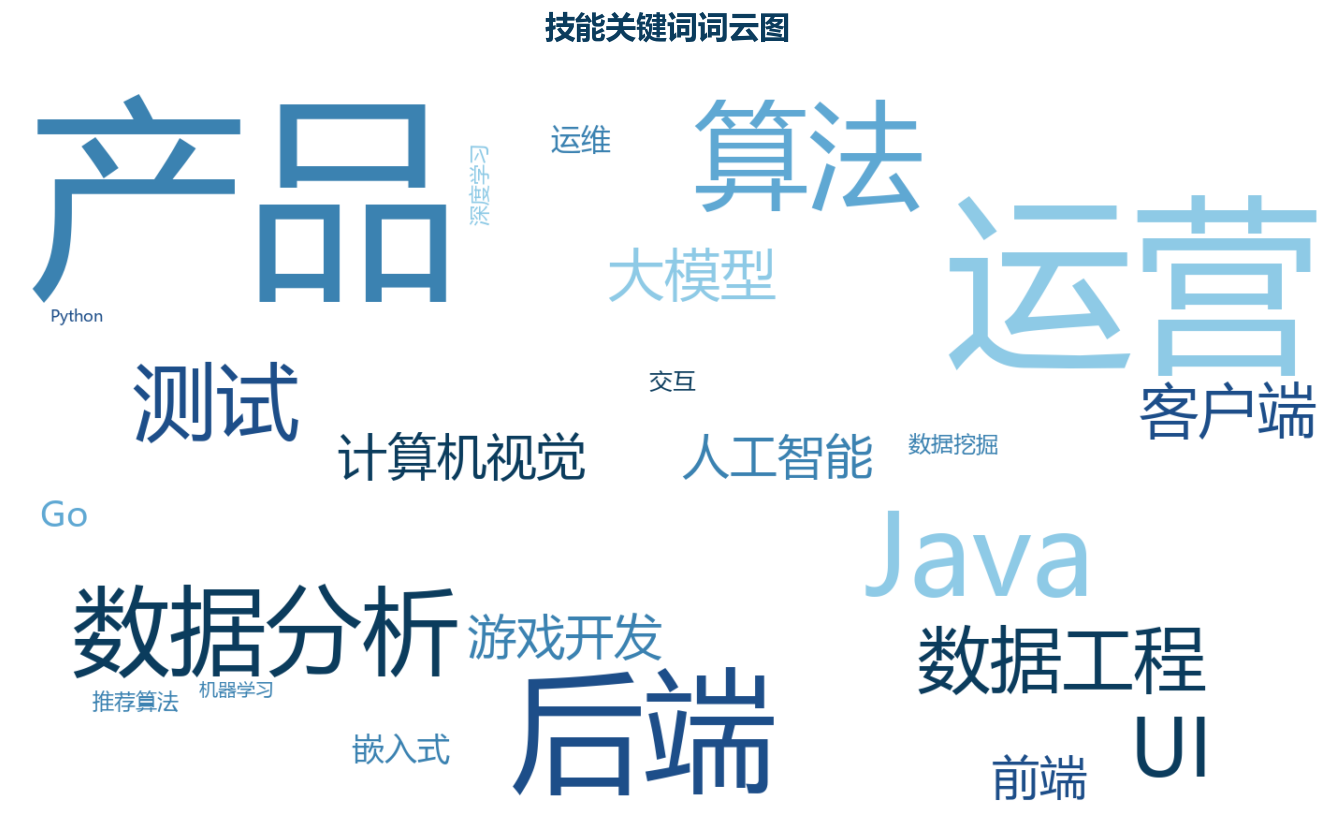

In [26]:
# 图 19：技能关键词词云图
try:
    from wordcloud import WordCloud
    import random

    font_path = find_chinese_font_path()

    if len(skill_freq) == 0:
        print("没有匹配到技能关键词，跳过词云图。")
    else:
        BLUE_SHADES = [
            "#0B3C5D",
            "#1D4E89",
            "#2E6F95",
            "#3B82B1",
            "#5FA8D3",
            "#8ECAE6"
        ]
        def blue_color_func(*args, **kwargs):
            return random.choice(BLUE_SHADES)
        wc = WordCloud(
            font_path=font_path,
            width=1400,
            height=800,
            background_color="white",
            max_words=100,
            prefer_horizontal=0.92,
            random_state=42,
            margin=4,
            collocations=False,
            max_font_size=230,
            min_font_size=16
        ).generate_from_frequencies(skill_freq.to_dict())

        wc = wc.recolor(color_func=blue_color_func, random_state=42)

        fig, ax = plt.subplots(figsize=(13, 7.5), facecolor="white")
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(
            "技能关键词词云图",
            fontsize=17,
            fontweight="bold",
            color="#0B3C5D",
            pad=16
        )

        save_and_show(fig, "19_技能关键词词云图.png")

except Exception as e:
    print("当前环境未成功生成词云图，可先运行：pip install wordcloud")
    print("错误信息：", e)

已保存：结果可视化\20_技能共现热力图.png


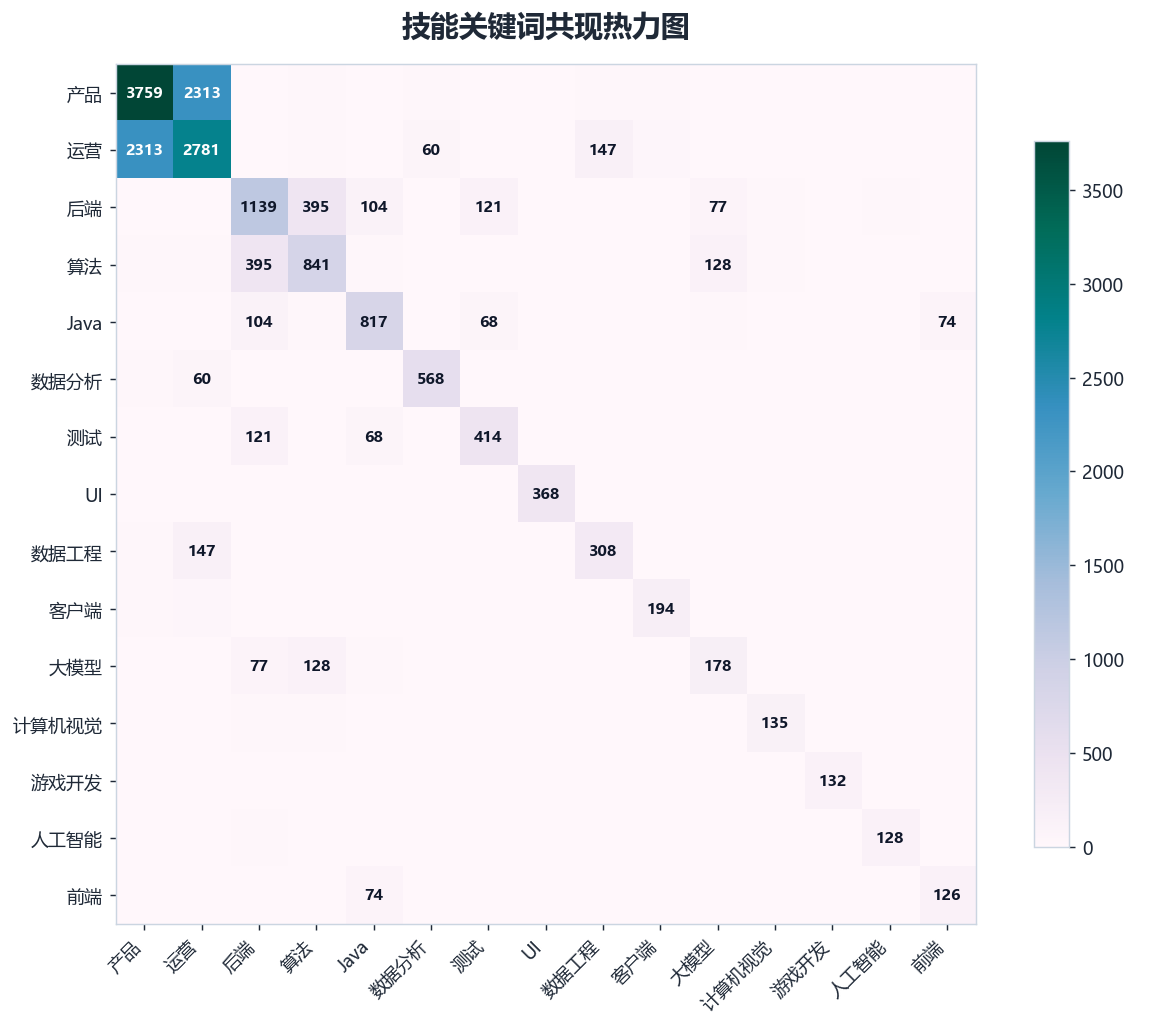

In [27]:
# 图 20：技能共现关系热力图
selected_skills = skill_freq.head(15).index.tolist()
co_mat = pd.DataFrame(0, index=selected_skills, columns=selected_skills, dtype=int)

for skills in df["skills"]:
    skills = [s for s in skills if s in selected_skills]
    for a, b in combinations(sorted(set(skills)), 2):
        co_mat.loc[a, b] += 1
        co_mat.loc[b, a] += 1

for s in selected_skills:
    co_mat.loc[s, s] = skill_freq.get(s, 0)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.PuBuGn
norm = plt.Normalize(vmin=co_mat.values.min(), vmax=co_mat.values.max())
im = ax.imshow(co_mat.values, cmap=cmap, norm=norm)

ax.set_xticks(np.arange(len(selected_skills)))
ax.set_yticks(np.arange(len(selected_skills)))
ax.set_xticklabels(selected_skills, rotation=45, ha="right")
ax.set_yticklabels(selected_skills)
ax.set_title("技能关键词共现热力图", fontsize=16, fontweight="bold",
             color=COLORS["dark"], pad=16)
threshold = np.nanpercentile(co_mat.values, 85)

for i in range(len(selected_skills)):
    for j in range(len(selected_skills)):
        v = co_mat.iloc[i, j]
        if v >= threshold and v > 0:
            # 取当前数值对应的背景颜色
            rgba = cmap(norm(v))
            r, g, b, _ = rgba

            # 计算亮度：亮背景用深字，暗背景用白字
            brightness = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "#0F172A" if brightness > 0.6 else "white"

            ax.text(
                j, i, str(v),
                ha="center", va="center",
                fontsize=8.5,
                fontweight="bold",
                color=text_color
            )

cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("共现次数 / 对角线为单技能频率")
fig.tight_layout()
save_and_show(fig, "20_技能共现热力图.png")

已保存：结果可视化\21_技能共现网络图.png


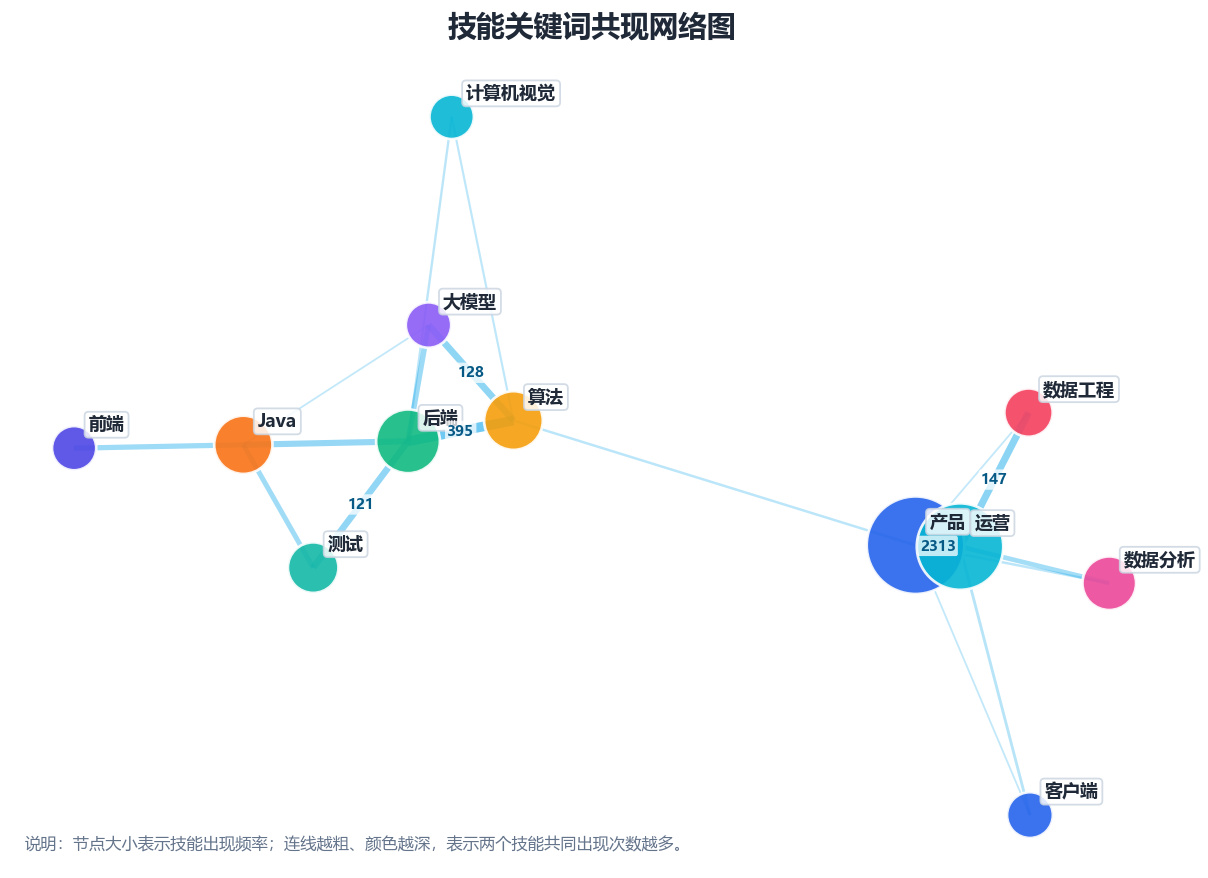

In [28]:
# 图 21：技能关键词共现网络图（强化连线粗细差异版）
try:
    import networkx as nx

    selected_skills = skill_freq.head(15).index.tolist()
    co_mat = pd.DataFrame(0, index=selected_skills, columns=selected_skills, dtype=int)
    for skills in df["skills"]:
        skills = [s for s in skills if s in selected_skills]
        for a, b in combinations(sorted(set(skills)), 2):
            co_mat.loc[a, b] += 1
            co_mat.loc[b, a] += 1
    for s in selected_skills:
        co_mat.loc[s, s] = skill_freq.get(s, 0)

    edges = []
    for i, a in enumerate(selected_skills):
        for b in selected_skills[i + 1:]:
            w = co_mat.loc[a, b]
            if w > 0:
                edges.append((a, b, int(w)))

    if not edges:
        skip_plot("技能关键词之间没有明显共现关系，跳过网络图。")
    else:
        edges = sorted(edges, key=lambda x: x[2], reverse=True)
        top_edges = edges[:18]
        G = nx.Graph()
        for a, b, w in top_edges:
            G.add_node(a, size=skill_freq.get(a, 1))
            G.add_node(b, size=skill_freq.get(b, 1))
            G.add_edge(a, b, weight=w)
        G.remove_nodes_from(list(nx.isolates(G)))
        fig, ax = plt.subplots(figsize=(11.5, 8))
        pos = nx.spring_layout(
            G,
            seed=42,
            k=1.05,
            iterations=500,
            weight="weight",
            scale=2.8
        )
        max_node_size = max([G.nodes[n]["size"] for n in G.nodes])
        node_sizes = [
            520 + G.nodes[n]["size"] / max_node_size * 2400
            for n in G.nodes
        ]
        weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
        log_weights = np.log1p(weights)
        w_min, w_max = log_weights.min(), log_weights.max()

        def edge_style(weight):
            if w_max == w_min:
                norm_w = 0.5
            else:
                norm_w = (np.log1p(weight) - w_min) / (w_max - w_min)

            width = 1.0 + norm_w * 7.0
            alpha = 0.25 + norm_w * 0.55
            return width, alpha

        sorted_edges_for_draw = sorted(G.edges(data=True), key=lambda x: x[2]["weight"])
        for u, v, d in sorted_edges_for_draw:
            width, alpha = edge_style(d["weight"])
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v)],
                ax=ax,
                width=width,
                alpha=alpha,
                edge_color="#0EA5E9"
            )
        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_size=node_sizes,
            node_color=get_discrete_colors(len(G.nodes)),
            alpha=0.90,
            edgecolors="white",
            linewidths=1.5
        )
        for node, (x, y) in pos.items():
            ax.annotate(
                node,
                xy=(x, y),
                xytext=(8, 8),
                textcoords="offset points",
                fontsize=10,
                fontweight="bold",
                color=COLORS["dark"],
                ha="left",
                va="bottom",
                bbox=dict(
                    facecolor="white",
                    edgecolor=COLORS["light_gray"],
                    alpha=0.84,
                    boxstyle="round,pad=0.22"
                )
            )
        strongest_edges = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:5]

        for u, v, d in strongest_edges:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            xm, ym = (x1 + x2) / 2, (y1 + y2) / 2

            ax.text(
                xm, ym,
                str(d["weight"]),
                fontsize=8,
                color="#075985",
                fontweight="bold",
                ha="center",
                va="center",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    boxstyle="round,pad=0.15"
                )
            )

        ax.set_title(
            "技能关键词共现网络图",
            fontsize=16,
            fontweight="bold",
            color=COLORS["dark"],
            pad=16
        )

        ax.text(
            0.01, 0.02,
            "说明：节点大小表示技能出现频率；连线越粗、颜色越深，表示两个技能共同出现次数越多。",
            transform=ax.transAxes,
            fontsize=9,
            color=COLORS["gray"]
        )

        ax.axis("off")
        save_and_show(fig, "21_技能共现网络图.png")

except Exception as e:
    print("当前环境未成功生成网络图，可先运行：pip install networkx")
    print("错误信息：", e)

## 八、交叉关系分析

前面主要是单变量或简单对比。这里进一步分析城市、薪资档位、岗位类型之间的交叉关系，用热力图呈现结构差异。

已保存：结果可视化\22_城市薪资档位热力图.png


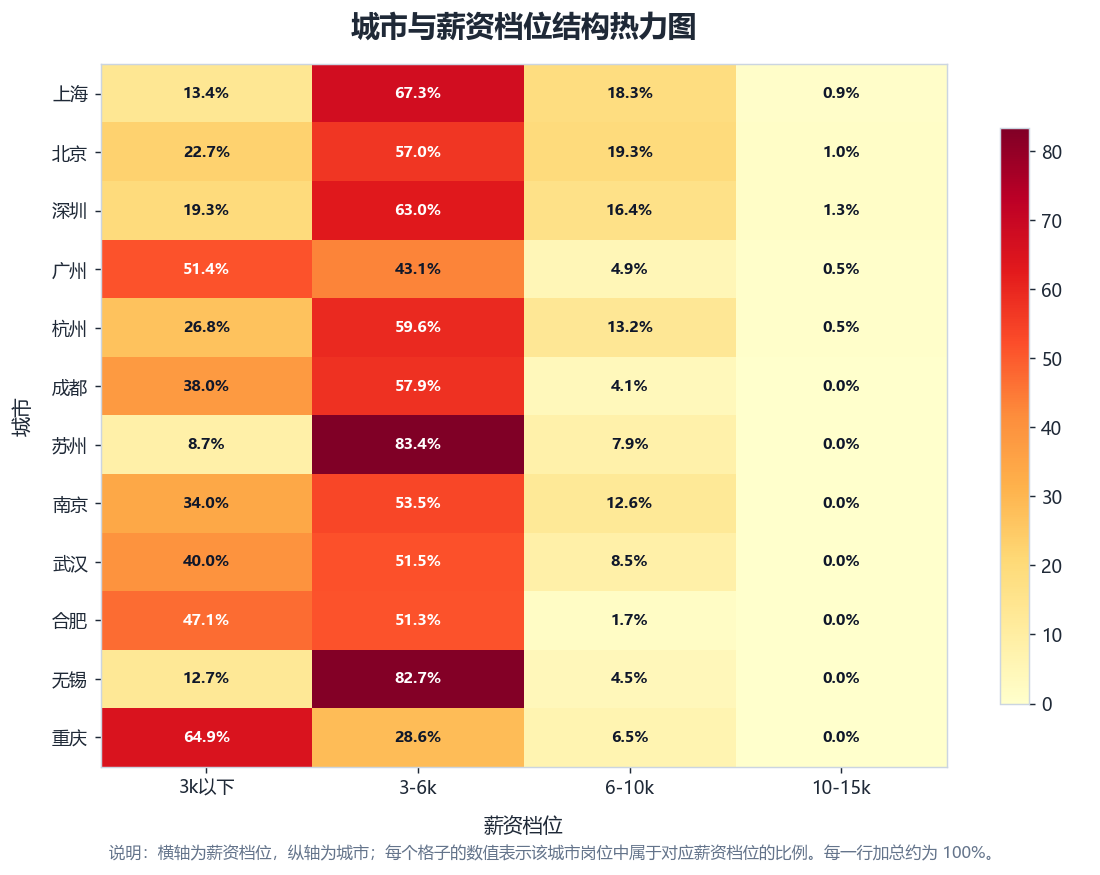

In [29]:
# 图 22：城市 × 薪资档位结构热力图
city_top = df["city_use"].value_counts().head(TOP_N_HEATMAP_CITY).index
salary_order = [x for x in SALARY_TIER_ORDER if x in df["salary_tier"].unique()]
heat = pd.crosstab(df["city_use"], df["salary_tier"])
heat = heat.loc[city_top, [c for c in salary_order if c in heat.columns]]
heat_pct = heat.div(heat.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(10.5, 7.4))
cmap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=heat_pct.values.min(), vmax=heat_pct.values.max())
im = ax.imshow(heat_pct.values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(np.arange(len(heat_pct.columns)))
ax.set_yticks(np.arange(len(heat_pct.index)))
ax.set_xticklabels(heat_pct.columns, fontsize=10)
ax.set_yticklabels(heat_pct.index, fontsize=10)

ax.set_xlabel("薪资档位", fontsize=11, color=COLORS["dark"], labelpad=10)
ax.set_ylabel("城市", fontsize=11, color=COLORS["dark"], labelpad=10)
ax.set_title(
    "城市与薪资档位结构热力图",
    fontsize=16,
    fontweight="bold",
    color=COLORS["dark"],
    pad=16
)
for i in range(heat_pct.shape[0]):
    for j in range(heat_pct.shape[1]):
        value = heat_pct.iloc[i, j]

        rgba = cmap(norm(value))
        r, g, b, _ = rgba
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = "#0F172A" if brightness > 0.58 else "white"
        ax.text(
            j, i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=text_color
        )

cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("该城市内部岗位占比（%）", fontsize=10)

# 底部说明文字
fig.subplots_adjust(bottom=0.15)

ax.text(
    0.01, -0.13,
    "说明：横轴为薪资档位，纵轴为城市；每个格子的数值表示该城市岗位中属于对应薪资档位的比例。每一行加总约为 100%。",
    transform=ax.transAxes,
    fontsize=9,
    color=COLORS["gray"]
)
save_and_show(fig, "22_城市薪资档位热力图.png")

已保存：结果可视化\23_城市岗位类型热力图.png


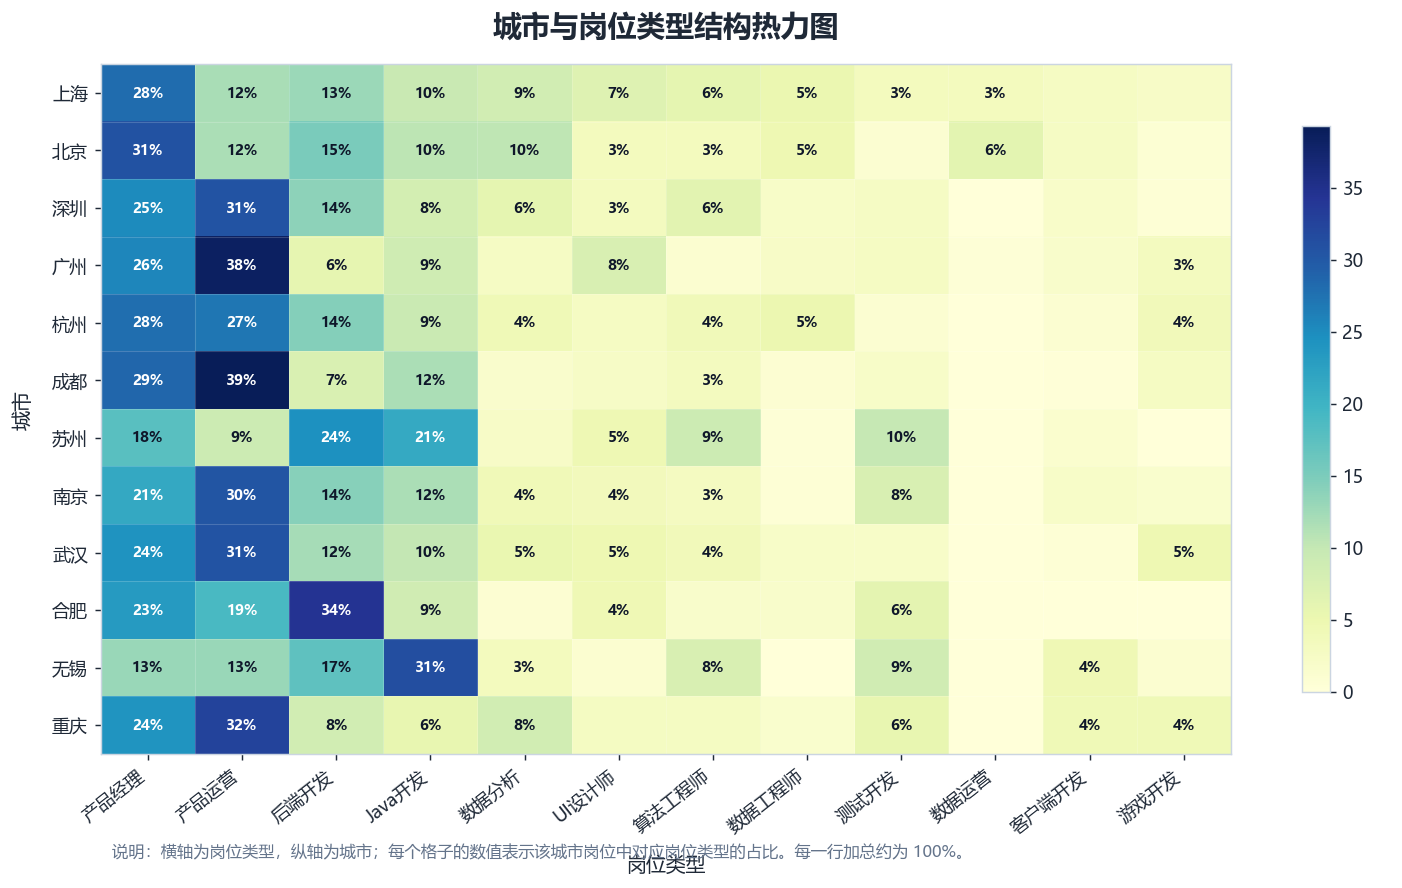

In [30]:
# 图 23：城市 × 岗位类型热力图（优化版）
city_top = df["city_use"].value_counts().head(TOP_N_HEATMAP_CITY).index
job_top = df["search_keyword"].value_counts().head(TOP_N_HEATMAP_JOB).index

# 交叉表
heat_job = pd.crosstab(df["city_use"], df["search_keyword"]).loc[city_top, job_top]

# 按城市内部归一化：每一行加总约等于100%
heat_job_pct = heat_job.div(heat_job.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13.5, 7.8))
cmap = plt.cm.YlGnBu
norm = plt.Normalize(vmin=0, vmax=heat_job_pct.values.max())
im = ax.imshow(heat_job_pct.values, cmap=cmap, norm=norm, aspect="auto")

# 坐标轴刻度
ax.set_xticks(np.arange(len(heat_job_pct.columns)))
ax.set_yticks(np.arange(len(heat_job_pct.index)))
ax.set_xticklabels([shorten_label(c, 8) for c in heat_job_pct.columns],
                   rotation=38, ha="right", fontsize=10)
ax.set_yticklabels(heat_job_pct.index, fontsize=10)
ax.set_xlabel("岗位类型", fontsize=11, color=COLORS["dark"], labelpad=10)
ax.set_ylabel("城市", fontsize=11, color=COLORS["dark"], labelpad=10)

ax.set_title(
    "城市与岗位类型结构热力图",
    fontsize=16,
    fontweight="bold",
    color=COLORS["dark"],
    pad=16
)
ax.set_xticks(np.arange(-0.5, len(heat_job_pct.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat_job_pct.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.6, alpha=0.18)
ax.tick_params(which="minor", bottom=False, left=False)

# 标注数值：只标注较有代表性的值，避免太挤
for i in range(heat_job_pct.shape[0]):
    for j in range(heat_job_pct.shape[1]):
        value = heat_job_pct.iloc[i, j]
        if value >= 3:   # 小于3%的格子不标，避免过密
            rgba = cmap(norm(value))
            r, g, b, _ = rgba
            brightness = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "#0F172A" if brightness > 0.62 else "white"

            ax.text(
                j, i,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
                color=text_color
            )
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("该城市内部岗位占比（%）", fontsize=10)
fig.subplots_adjust(bottom=0.20, right=0.93)
ax.text(
    0.01, -0.15,
    "说明：横轴为岗位类型，纵轴为城市；每个格子的数值表示该城市岗位中对应岗位类型的占比。每一行加总约为 100%。",
    transform=ax.transAxes,
    fontsize=9,
    color=COLORS["gray"]
)
save_and_show(fig, "23_城市岗位类型热力图.png")

已保存：结果可视化\24_竞争力评分与薪资散点图.png


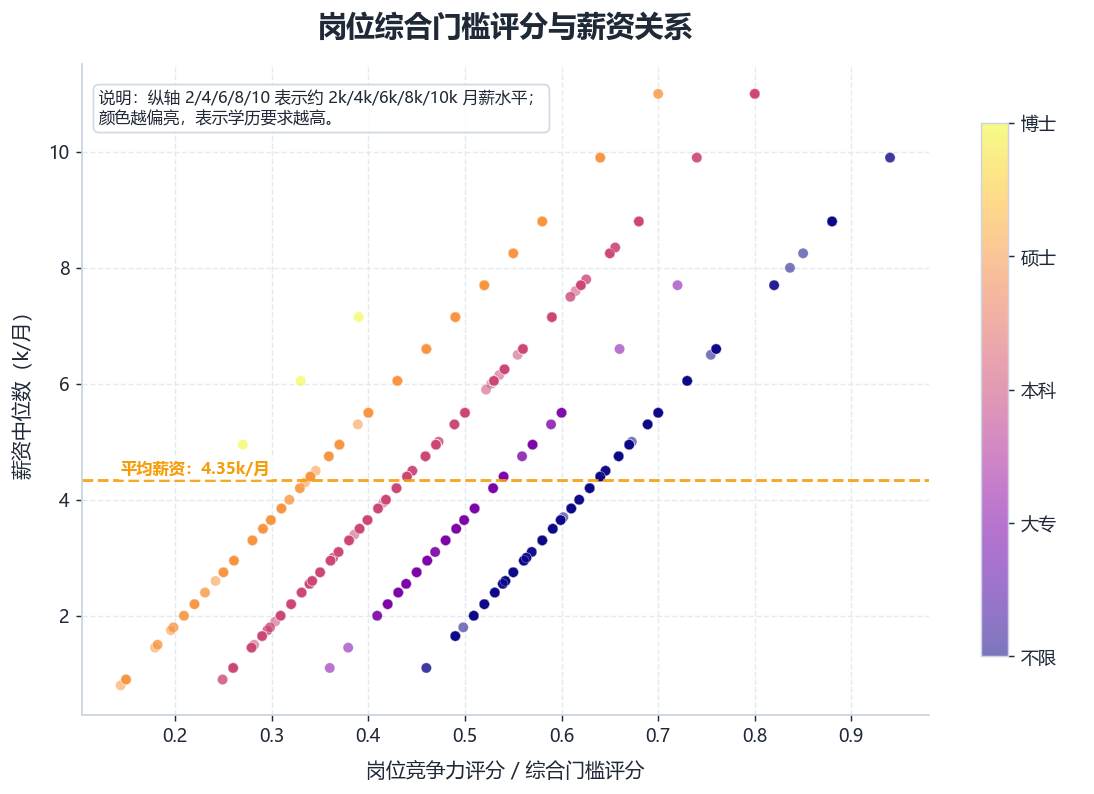

In [31]:
# 图 24：岗位综合门槛评分与薪资关系散点图
plot_df = (
    df.dropna(subset=["salary_mid", "edu_score", "competitiveness_score"])
      .sample(min(2500, len(df)), random_state=42)
)

fig, ax = plt.subplots(figsize=(10.5, 6.5))

sc = ax.scatter(
    plot_df["competitiveness_score"],
    plot_df["salary_mid"],
    c=plot_df["edu_score"],
    cmap="plasma",
    s=32,
    alpha=0.55,
    edgecolor="white",
    linewidth=0.25
)

style_ax(
    ax,
    "岗位综合门槛评分与薪资关系",
    "岗位竞争力评分 / 综合门槛评分",
    "薪资中位数（k/月）",
    grid_axis="both"
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.82)
cbar.set_label("学历要求分数", fontsize=10)
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(["不限", "大专", "本科", "硕士", "博士"])

ax.text(
    0.02, 0.96,
    "说明：纵轴 2/4/6/8/10 表示约 2k/4k/6k/8k/10k 月薪水平；\n"
    "颜色越偏亮，表示学历要求越高。",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color=COLORS["dark"],
    bbox=dict(
        facecolor="white",
        edgecolor=COLORS["light_gray"],
        alpha=0.86,
        boxstyle="round,pad=0.35"
    )
)
avg_salary = plot_df["salary_mid"].mean()
ax.axhline(
    avg_salary,
    color=COLORS["amber"],
    linestyle="--",
    linewidth=1.6,
    alpha=0.9
)

ax.text(
    plot_df["competitiveness_score"].min(),
    avg_salary + 0.12,
    f"平均薪资：{avg_salary:.2f}k/月",
    color=COLORS["amber"],
    fontsize=9,
    fontweight="bold",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.75,
        boxstyle="round,pad=0.2"
    )
)

save_and_show(fig, "24_竞争力评分与薪资散点图.png")

已保存：结果可视化\25_数值变量相关性热力图.png


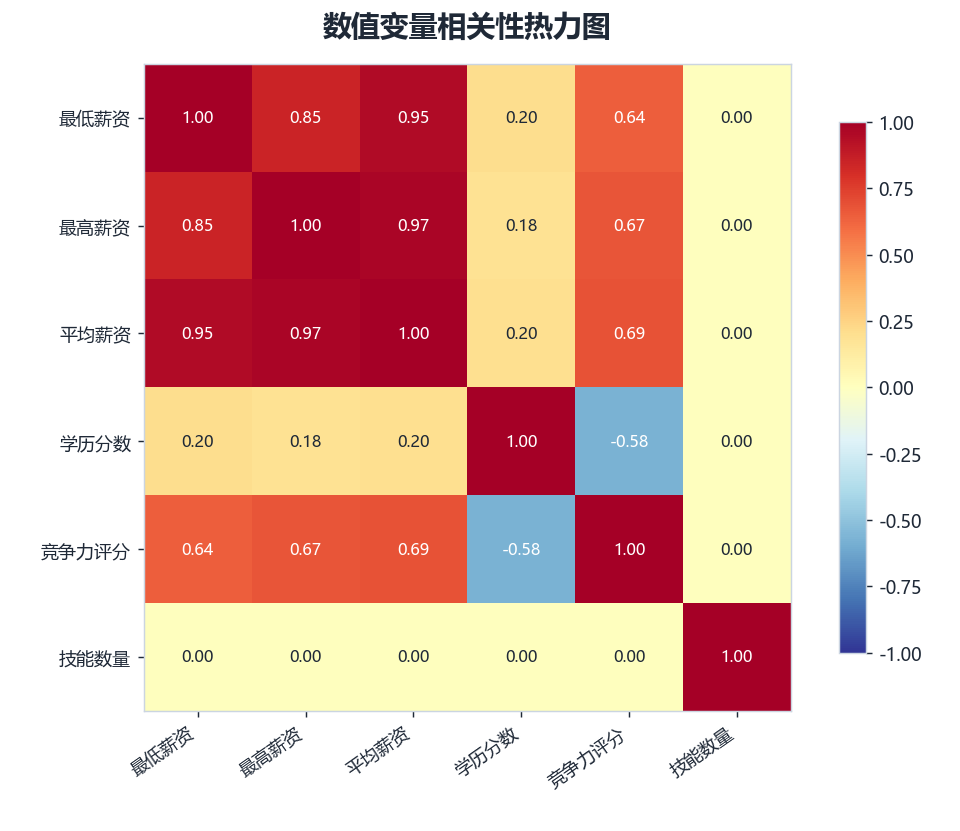

In [32]:
# 图 25：数值变量相关性热力图
num_cols = [c for c in [
    "salary_min", "salary_max", "salary_mid",
    "edu_score", "competitiveness_score", "skill_count"
] if c in df.columns]

corr = df[num_cols].corr(numeric_only=True)
col_name_map = {
    "salary_min": "最低薪资",
    "salary_max": "最高薪资",
    "salary_mid": "平均薪资",
    "edu_score": "学历分数",
    "competitiveness_score": "竞争力评分",
    "skill_count": "技能数量"
}

cn_labels = [col_name_map.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(corr.values, cmap="RdYlBu_r", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(cn_labels, rotation=35, ha="right")
ax.set_yticklabels(cn_labels)

ax.set_title(
    "数值变量相关性热力图",
    fontsize=16,
    fontweight="bold",
    color=COLORS["dark"],
    pad=16
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.iloc[i, j]
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            fontsize=9,
            color="white" if abs(val) >= 0.55 else COLORS["dark"]
        )

cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("相关系数", fontsize=10)
ax.set_xlabel("变量", fontsize=11)
ax.set_ylabel("变量", fontsize=11)

fig.tight_layout()
save_and_show(fig, "25_数值变量相关性热力图.png")

## 九、综合画像图

最后用雷达图把主要城市的“岗位数量、平均薪资、岗位类型丰富度、平均学历要求、平均技能数”放在一起比较，适合作为汇报中的综合收束图。

已保存：结果可视化\26_Top城市综合画像雷达图.png


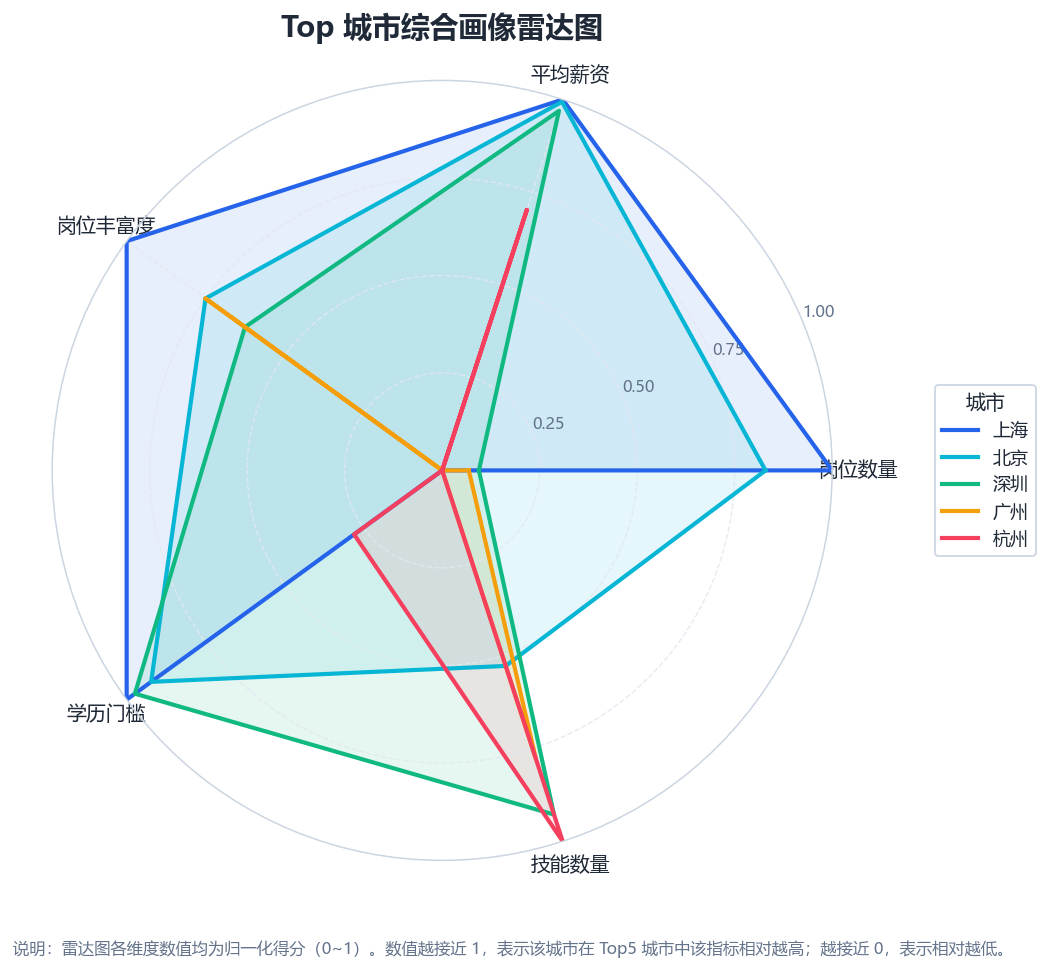

In [33]:
# 图 26：Top 城市综合画像雷达图

city_profile = (
    df.groupby("city_use")
      .agg(
          job_count=("job_title", "count"),
          avg_salary=("salary_mid", "mean"),
          job_diversity=("search_keyword", "nunique"),
          avg_edu=("edu_score", "mean"),
          avg_skill_count=("skill_count", "mean"),
      )
      .sort_values("job_count", ascending=False)
      .head(5)
)
profile_norm = city_profile.copy()
for col in profile_norm.columns:
    col_min = profile_norm[col].min()
    col_max = profile_norm[col].max()
    if col_max > col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)
    else:
        profile_norm[col] = 0.5

labels = ["岗位数量", "平均薪资", "岗位丰富度", "学历门槛", "技能数量"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9.5, 8), subplot_kw=dict(polar=True))
for i, city in enumerate(profile_norm.index):
    values = profile_norm.loc[city].tolist()
    values += values[:1]
    ax.plot(
        angles,
        values,
        color=PALETTE[i % len(PALETTE)],
        linewidth=2.3,
        label=city
    )
    ax.fill(
        angles,
        values,
        color=PALETTE[i % len(PALETTE)],
        alpha=0.10
    )
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, color=COLORS["dark"])
ax.set_ylim(0, 1.0)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(
    ["0.25", "0.50", "0.75", "1.00"],
    fontsize=9,
    color=COLORS["gray"]
)
ax.set_title(
    "Top 城市综合画像雷达图",
    fontsize=16,
    fontweight="bold",
    color=COLORS["dark"],
    pad=24
)
ax.grid(color=COLORS["grid"], linestyle="--", alpha=0.85)
legend = ax.legend(
    title="城市",
    loc="center left",
    bbox_to_anchor=(1.12, 0.5),
    frameon=True,
    facecolor="white",
    edgecolor=COLORS["light_gray"],
    framealpha=0.96,
    fontsize=10,
    title_fontsize=11
)
for text in legend.get_texts():
    text.set_color(COLORS["dark"])
legend.get_title().set_color(COLORS["dark"])
fig.text(
    0.5, 0.04,
    "说明：雷达图各维度数值均为归一化得分（0~1）。数值越接近 1，表示该城市在 Top5 城市中该指标相对越高；越接近 0，表示相对越低。",
    ha="center",
    fontsize=9,
    color=COLORS["gray"]
)

# 给右侧图例和底部说明留空间
fig.subplots_adjust(right=0.76, bottom=0.13, top=0.88)

save_and_show(fig, "26_Top城市综合画像雷达图.png")

In [34]:
# 查看当前已经保存的图片文件
saved_files = sorted(OUTPUT_DIR.glob("*.png"))
print(f"当前已保存 {len(saved_files)} 张图片：")
for f in saved_files:
    print("-", f.name)

当前已保存 26 张图片：
- 01_数据概览信息卡.png
- 02_城市岗位数量排名.png
- 03_城市岗位数量与平均薪资对比.png
- 04_城市地理气泡图.png
- 05_城市岗位集中度帕累托图.png
- 06_薪资整体分布直方图.png
- 07_薪资档位占比甜甜圈图.png
- 08_主要城市薪资分布箱线图.png
- 09_主要岗位类型薪资分布箱线图.png
- 10_学历要求占比.png
- 11_学历要求与平均薪资.png
- 12_公司规模与岗位数量平均薪资.png
- 13_行业平均薪资排名.png
- 14_岗位类型需求量排名.png
- 15_岗位类型平均薪资排名.png
- 16_岗位类型需求薪资学历气泡图.png
- 17_城市岗位类型结构堆叠图.png
- 18_技能关键词频率条形图.png
- 19_技能关键词词云图.png
- 20_技能共现热力图.png
- 21_技能共现网络图.png
- 22_城市薪资档位热力图.png
- 23_城市岗位类型热力图.png
- 24_竞争力评分与薪资散点图.png
- 25_数值变量相关性热力图.png
- 26_Top城市综合画像雷达图.png
